# 01 EDA and Features

## P1 · Time-Series EDA

This section is P1 only. It reads the P0 panel artifact, profiles the time series, and writes P1 tables/figures. It does not build features, train forecasting models, or inspect supporting exogenous relationships beyond store metadata needed to define hierarchy levels.

In [1]:
from pathlib import Path
import os
import warnings

import matplotlib
import numpy as np
import pandas as pd
from IPython.display import Image, display
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import acf, adfuller, kpss, pacf
%matplotlib inline
warnings.filterwarnings("ignore")

CWD = Path.cwd().resolve()
if (CWD / "data" / "interim" / "panel.parquet").exists():
    PROJECT_ROOT = CWD
elif (CWD.parent / "data" / "interim" / "panel.parquet").exists():
    PROJECT_ROOT = CWD.parent
else:
    raise FileNotFoundError(
        "Run this notebook from the repo root or notebooks/ after P0 builds data/interim/panel.parquet"
    )

os.environ.setdefault("MPLCONFIGDIR", str(PROJECT_ROOT / "outputs" / ".matplotlib"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)
import matplotlib.pyplot as plt

PANEL_PATH = PROJECT_ROOT / "data" / "interim" / "panel.parquet"
STORES_PATH = PROJECT_ROOT / "data" / "raw" / "favorita" / "stores.csv"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures" / "p1_ts_eda"
TABLE_DIR = PROJECT_ROOT / "outputs" / "metrics" / "p1_ts_eda"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use("default")

### Helper Functions

Notebook helpers are kept top-level and pandas-first. No nested functions are used.

In [2]:
def save_and_show(fig: plt.Figure, path: Path) -> None:
    fig.tight_layout()
    fig.savefig(path, dpi=140, bbox_inches="tight")
    display_saved_image(path)
    plt.close(fig)


def display_saved_image(path: Path) -> None:
    display(Image(filename=str(path)))


def demand_segment(adi: float, cv2: float) -> str:
    if adi < 1.32 and cv2 < 0.49:
        return "smooth"
    if adi < 1.32 and cv2 >= 0.49:
        return "erratic"
    if adi >= 1.32 and cv2 < 0.49:
        return "intermittent"
    return "lumpy"


def lag_autocorrelation(values: pd.Series, lag: int) -> float:
    clean = values.astype(float).to_numpy()
    if len(clean) <= lag:
        return np.nan
    left = clean[:-lag]
    right = clean[lag:]
    if np.std(left) == 0 or np.std(right) == 0:
        return np.nan
    return float(np.corrcoef(left, right)[0, 1])


def stationarity_result(name: str, values: pd.Series) -> dict:
    clean = values.astype(float).dropna()
    diffed = clean.diff().dropna()
    return {
        "series": name,
        "adf_p": adfuller(clean, autolag="AIC")[1],
        "kpss_p": kpss(clean, regression="c", nlags="auto")[1],
        "diff_adf_p": adfuller(diffed, autolag="AIC")[1],
        "diff_kpss_p": kpss(diffed, regression="c", nlags="auto")[1],
    }


def hierarchy_daily(frame: pd.DataFrame, keys: list, name: str) -> pd.DataFrame:
    if keys:
        grouped = frame.groupby(keys + ["date"], observed=True, as_index=False)["sales"].sum()
        grouped["level"] = name
        grouped["series_id"] = grouped[keys].astype(str).agg("|".join, axis=1)
        return grouped[["level", "series_id", "date", "sales"]]
    grouped = frame.groupby("date", as_index=False)["sales"].sum()
    grouped["level"] = name
    grouped["series_id"] = "total"
    return grouped[["level", "series_id", "date", "sales"]]


def zero_rate_summary(frame: pd.DataFrame, keys: list, name: str) -> dict:
    daily = hierarchy_daily(frame, keys, name)
    return {
        "level": name,
        "series_count": daily["series_id"].nunique(),
        "rows": len(daily),
        "zero_rate": float((daily["sales"] == 0).mean()),
        "mean_daily_sales": float(daily["sales"].mean()),
    }


def stationarity_sample(frame: pd.DataFrame, limit: int) -> pd.DataFrame:
    totals = frame.groupby("series_id", observed=True)["sales"].sum().sort_values(ascending=False)
    rows = []
    for series_id in totals.head(limit).index:
        values = frame.loc[frame["series_id"] == series_id].sort_values("date").set_index("date")["sales"].asfreq("D").fillna(0)
        rows.append(stationarity_result(str(series_id), values))
    return pd.DataFrame(rows)


def acf_table(name: str, values: pd.Series, nlags: int) -> pd.DataFrame:
    acf_values = acf(values, nlags=nlags, fft=True)
    pacf_values = pacf(values, nlags=nlags, method="ywm")
    rows = []
    for lag, value in enumerate(acf_values):
        rows.append({"series": name, "kind": "acf", "lag": lag, "value": value})
    for lag, value in enumerate(pacf_values):
        rows.append({"series": name, "kind": "pacf", "lag": lag, "value": value})
    return pd.DataFrame(rows)


def plot_acf_pacf(name: str, values: pd.Series, nlags: int, path: Path) -> pd.DataFrame:
    table = acf_table(name, values, nlags)
    acf_values = table.loc[table["kind"] == "acf", "value"].to_numpy()
    pacf_values = table.loc[table["kind"] == "pacf", "value"].to_numpy()
    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
    axes[0].bar(range(len(acf_values)), acf_values)
    axes[0].set_title(f"{name} ACF")
    axes[1].bar(range(len(pacf_values)), pacf_values)
    axes[1].set_title(f"{name} PACF")
    axes[1].set_xlabel("Lag")
    save_and_show(fig, path)
    return table

### Load P0 Panel

The notebook starts from the P0 artifact required by the constitution.

In [3]:
panel = pd.read_parquet(PANEL_PATH)
stores = pd.read_csv(STORES_PATH)
panel["date"] = pd.to_datetime(panel["date"])
joined = panel.merge(stores, on="store_nbr", how="left")

panel_summary = pd.DataFrame(
    {
        "rows": [len(panel)],
        "min_date": [panel["date"].min().date()],
        "max_date": [panel["date"].max().date()],
        "bottom_series": [panel[["store_nbr", "family"]].drop_duplicates().shape[0]],
    }
)
panel_summary.to_csv(TABLE_DIR / "panel_summary.csv", index=False)
panel_summary

,rows,min_date,max_date,bottom_series
0,2450500,2013-01-01,2017-08-15,1729


### Figure Gallery

These images are generated by the P1 cells below and embedded here so the notebook has visible plots when opened after execution.

![Total daily sales](../outputs/figures/p1_ts_eda/total_daily_sales.png)

![Total weekly sales](../outputs/figures/p1_ts_eda/total_weekly_sales.png)

![Intermittency segment counts](../outputs/figures/p1_ts_eda/intermittency_segment_counts.png)

![Zero rate by level](../outputs/figures/p1_ts_eda/zero_rate_by_level.png)

![Daily STL decomposition](../outputs/figures/p1_ts_eda/daily_total_stl.png)

![Weekly STL decomposition](../outputs/figures/p1_ts_eda/weekly_total_stl.png)

![Daily ACF PACF](../outputs/figures/p1_ts_eda/daily_total_acf_pacf.png)

![Weekly ACF PACF](../outputs/figures/p1_ts_eda/weekly_total_acf_pacf.png)

![Bottom zero-rate distribution](../outputs/figures/p1_ts_eda/bottom_zero_rate_distribution.png)

### Series Inventory and Intermittency

Inventory covers active post-P0 bottom series, launch date, available history length, zero rate, and inactive final-period series.

In [4]:
bottom_groups = panel.groupby(["store_nbr", "family"], observed=True)
series_inventory = bottom_groups.agg(
    start_date=("date", "min"),
    end_date=("date", "max"),
    n_days=("date", "size"),
    zero_rate=("sales", lambda values: float((values == 0).mean())),
    total_sales=("sales", "sum"),
    positive_days=("sales", lambda values: int((values > 0).sum())),
).reset_index()
positive = panel.loc[panel["sales"] > 0].groupby(["store_nbr", "family"], observed=True)["sales"]
positive_stats = positive.agg(positive_mean="mean", positive_std="std").reset_index()
series_inventory = series_inventory.merge(positive_stats, on=["store_nbr", "family"], how="left")
series_inventory["adi"] = series_inventory["n_days"] / series_inventory["positive_days"]
series_inventory["cv2"] = (series_inventory["positive_std"] / series_inventory["positive_mean"]) ** 2
series_inventory["cv2"] = series_inventory["cv2"].fillna(0)
series_inventory["intermittency_segment"] = [
    demand_segment(adi, cv2) for adi, cv2 in zip(series_inventory["adi"], series_inventory["cv2"])
]
last_date = panel["date"].max()
recent = (
    panel.loc[panel["date"] > last_date - pd.Timedelta(days=90)]
    .groupby(["store_nbr", "family"], observed=True)["sales"]
    .sum()
    .rename("last_90_sales")
    .reset_index()
)
series_inventory = series_inventory.merge(recent, on=["store_nbr", "family"], how="left")
series_inventory["dead_last_90_days"] = series_inventory["last_90_sales"].fillna(0).eq(0)
series_inventory.to_csv(TABLE_DIR / "series_inventory.csv", index=False)

inventory_summary = pd.DataFrame(
    {
        "active_series": [len(series_inventory)],
        "min_days": [series_inventory["n_days"].min()],
        "median_days": [series_inventory["n_days"].median()],
        "max_days": [series_inventory["n_days"].max()],
        "mean_zero_rate": [series_inventory["zero_rate"].mean()],
        "dead_last_90_days": [int(series_inventory["dead_last_90_days"].sum())],
    }
)
inventory_summary.to_csv(TABLE_DIR / "inventory_summary.csv", index=False)
inventory_summary

,active_series,min_days,median_days,max_days,mean_zero_rate,dead_last_90_days
0,1729,37,1686.0,1688,0.181381,31


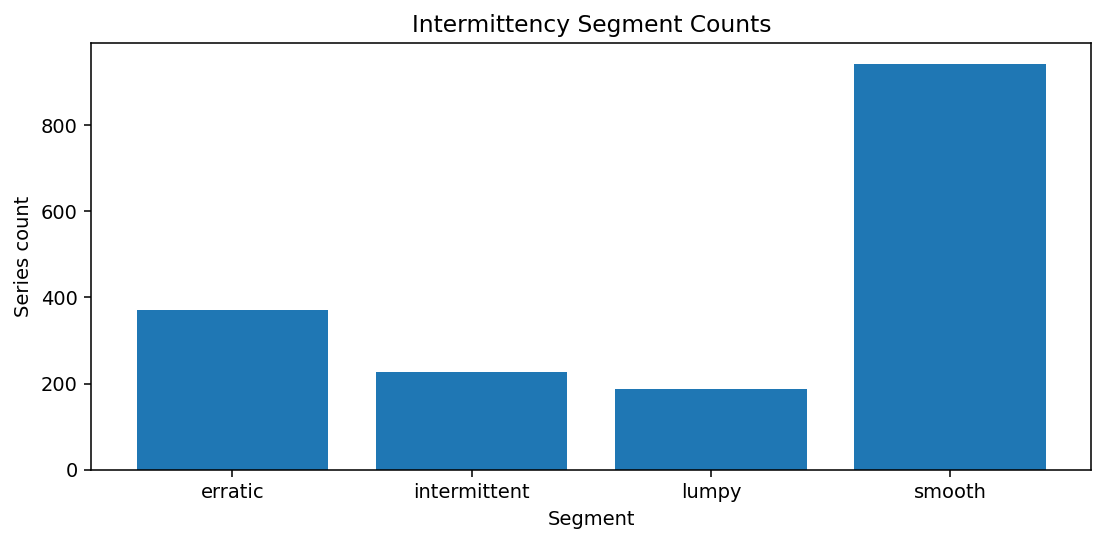

In [5]:
intermittency_counts = (
    series_inventory.groupby("intermittency_segment", observed=True)
    .size()
    .rename("series_count")
    .reset_index()
    .sort_values("intermittency_segment")
)
intermittency_counts.to_csv(TABLE_DIR / "intermittency_segments.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(intermittency_counts["intermittency_segment"], intermittency_counts["series_count"])
ax.set_title("Intermittency Segment Counts")
ax.set_xlabel("Segment")
ax.set_ylabel("Series count")
save_and_show(fig, FIGURE_DIR / "intermittency_segment_counts.png")
#intermittency_counts
plt.show()

### Zero Rate by Hierarchy Level

This checks the constitution's model-to-level assumption that upper levels are dense while bottom store-family series are intermittent.

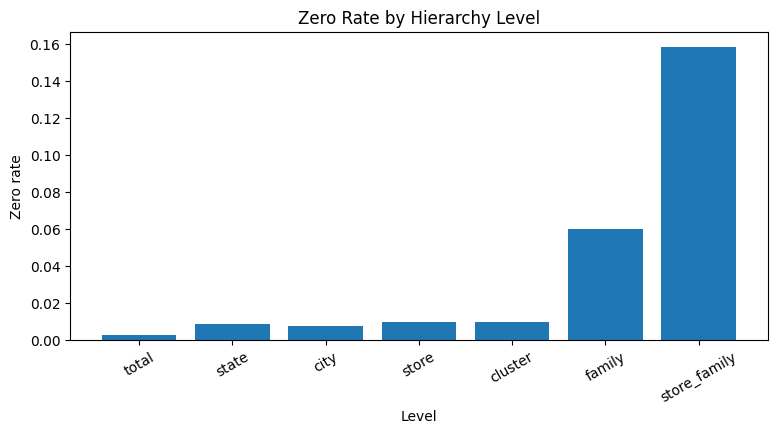

In [6]:
level_specs = [
    ([], "total"),
    (["state"], "state"),
    (["city"], "city"),
    (["store_nbr"], "store"),
    (["cluster"], "cluster"),
    (["family"], "family"),
    (["store_nbr", "family"], "store_family"),
]
zero_rate_by_level = pd.DataFrame([zero_rate_summary(joined, keys, name) for keys, name in level_specs])
zero_rate_by_level.to_csv(TABLE_DIR / "zero_rate_by_level.csv", index=False)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(zero_rate_by_level["level"], zero_rate_by_level["zero_rate"])
ax.set_title("Zero Rate by Hierarchy Level")
ax.set_xlabel("Level")
ax.set_ylabel("Zero rate")
ax.tick_params(axis="x", rotation=30)
#save_and_show(fig, FIGURE_DIR / "zero_rate_by_level.png")
zero_rate_by_level
plt.show()

### Total Series Shape and Decomposition

Daily and weekly total series show trend, weekly/annual structure, and whether weekly grain is defensible.

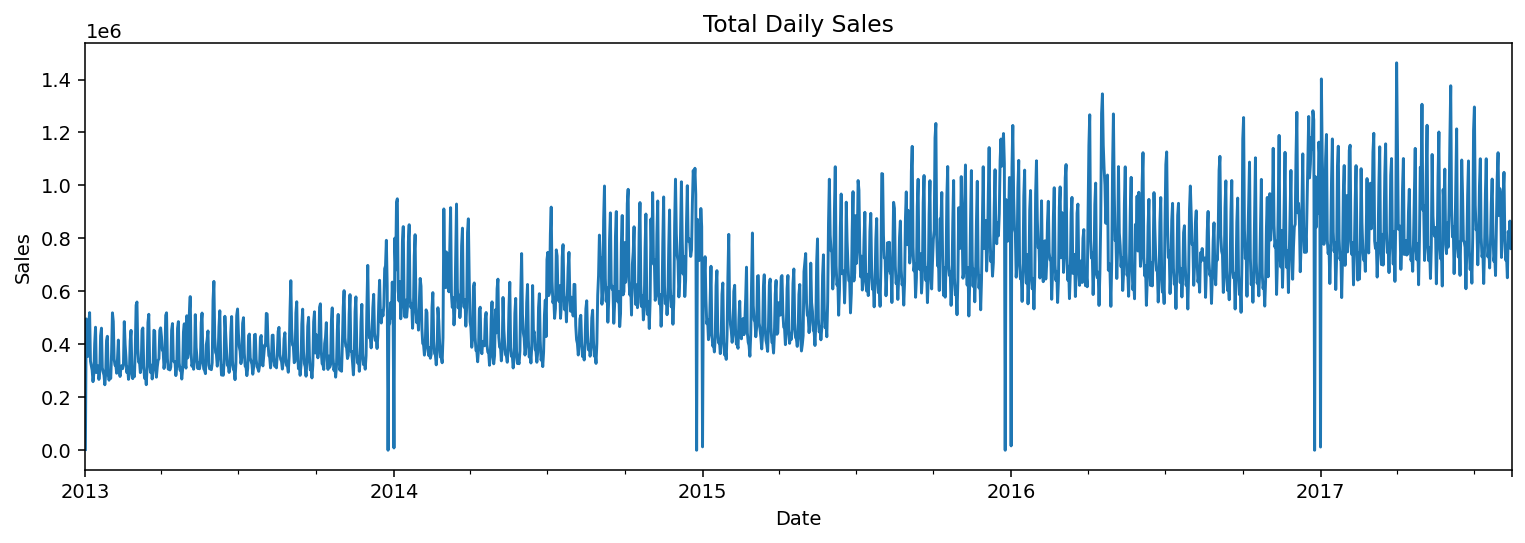

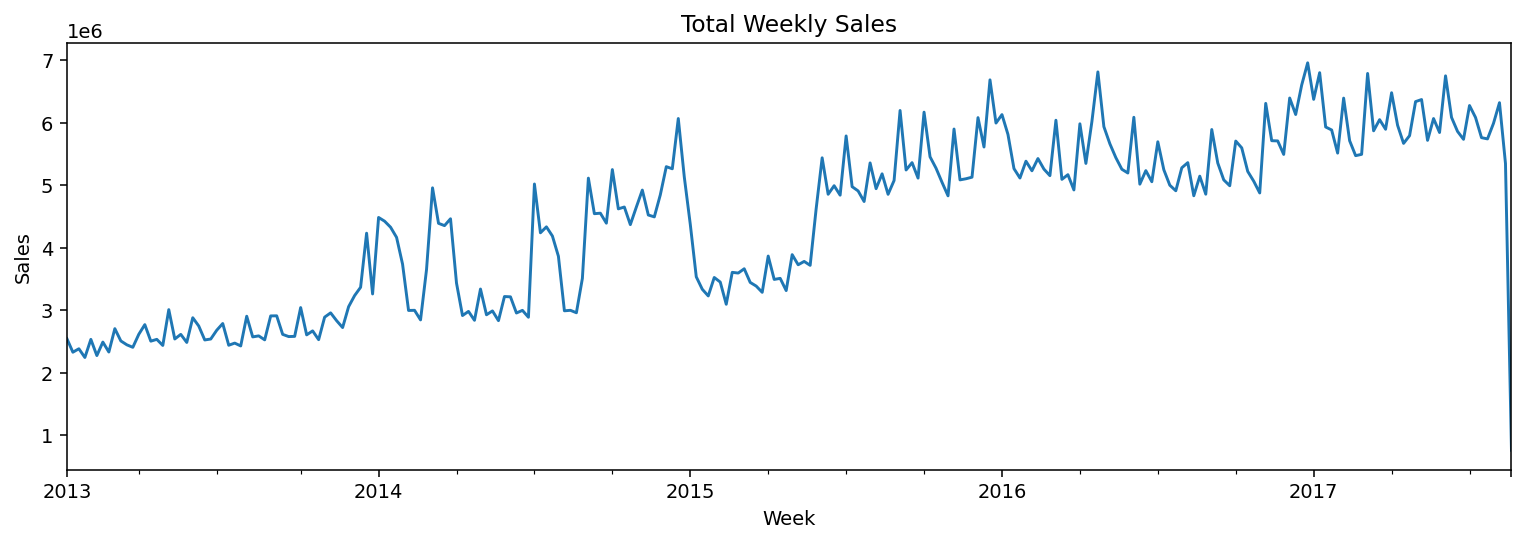

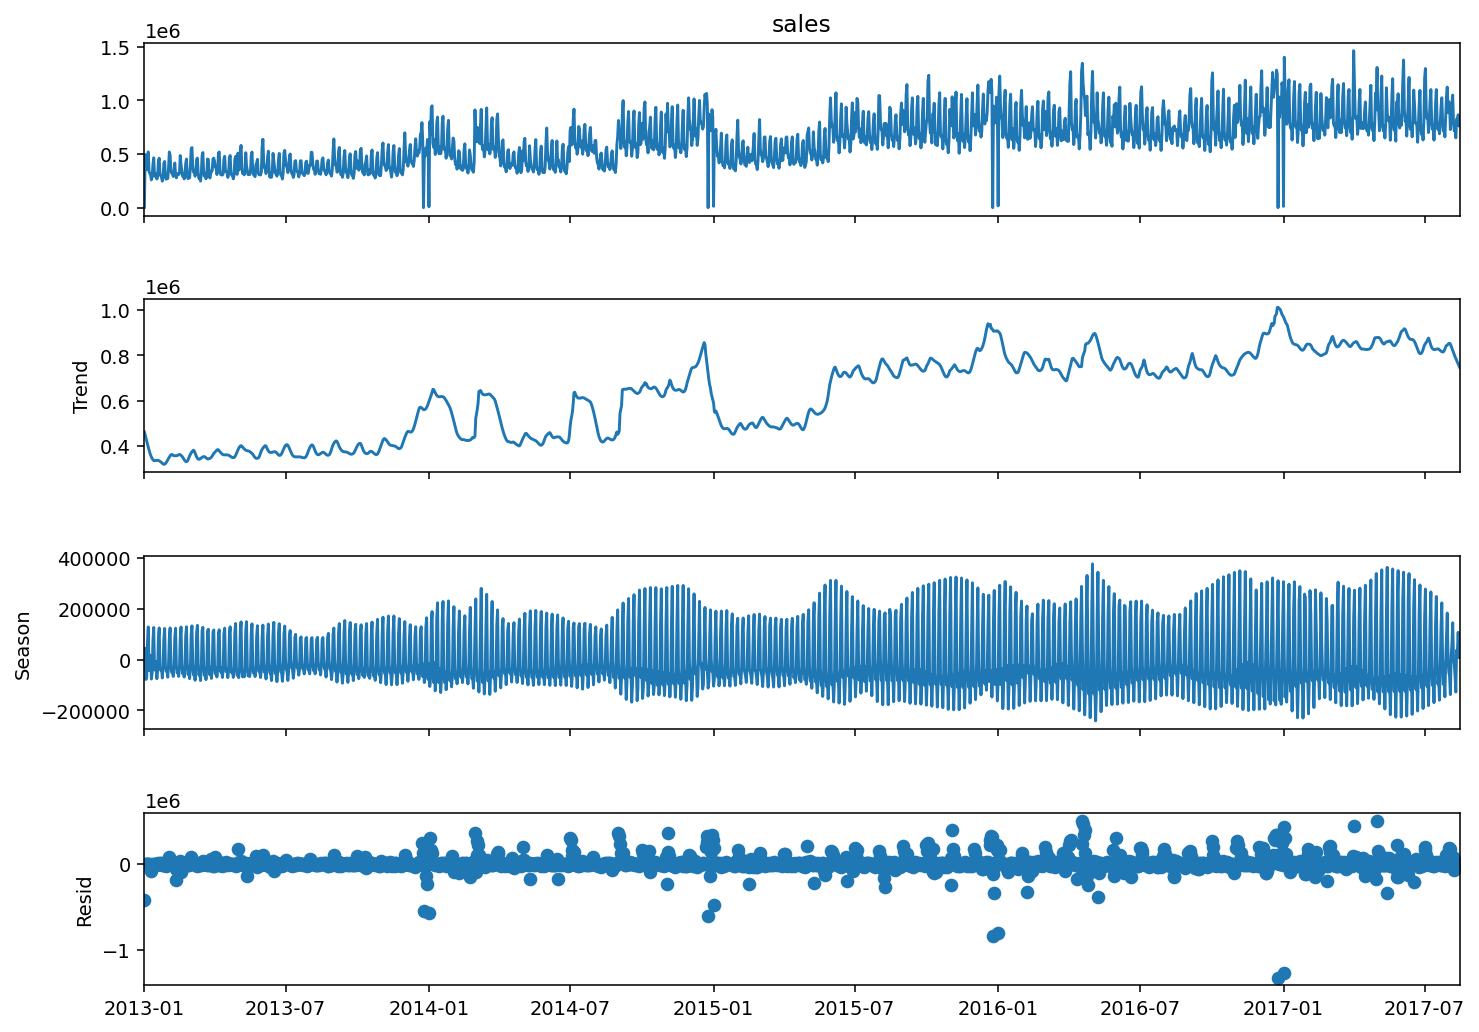

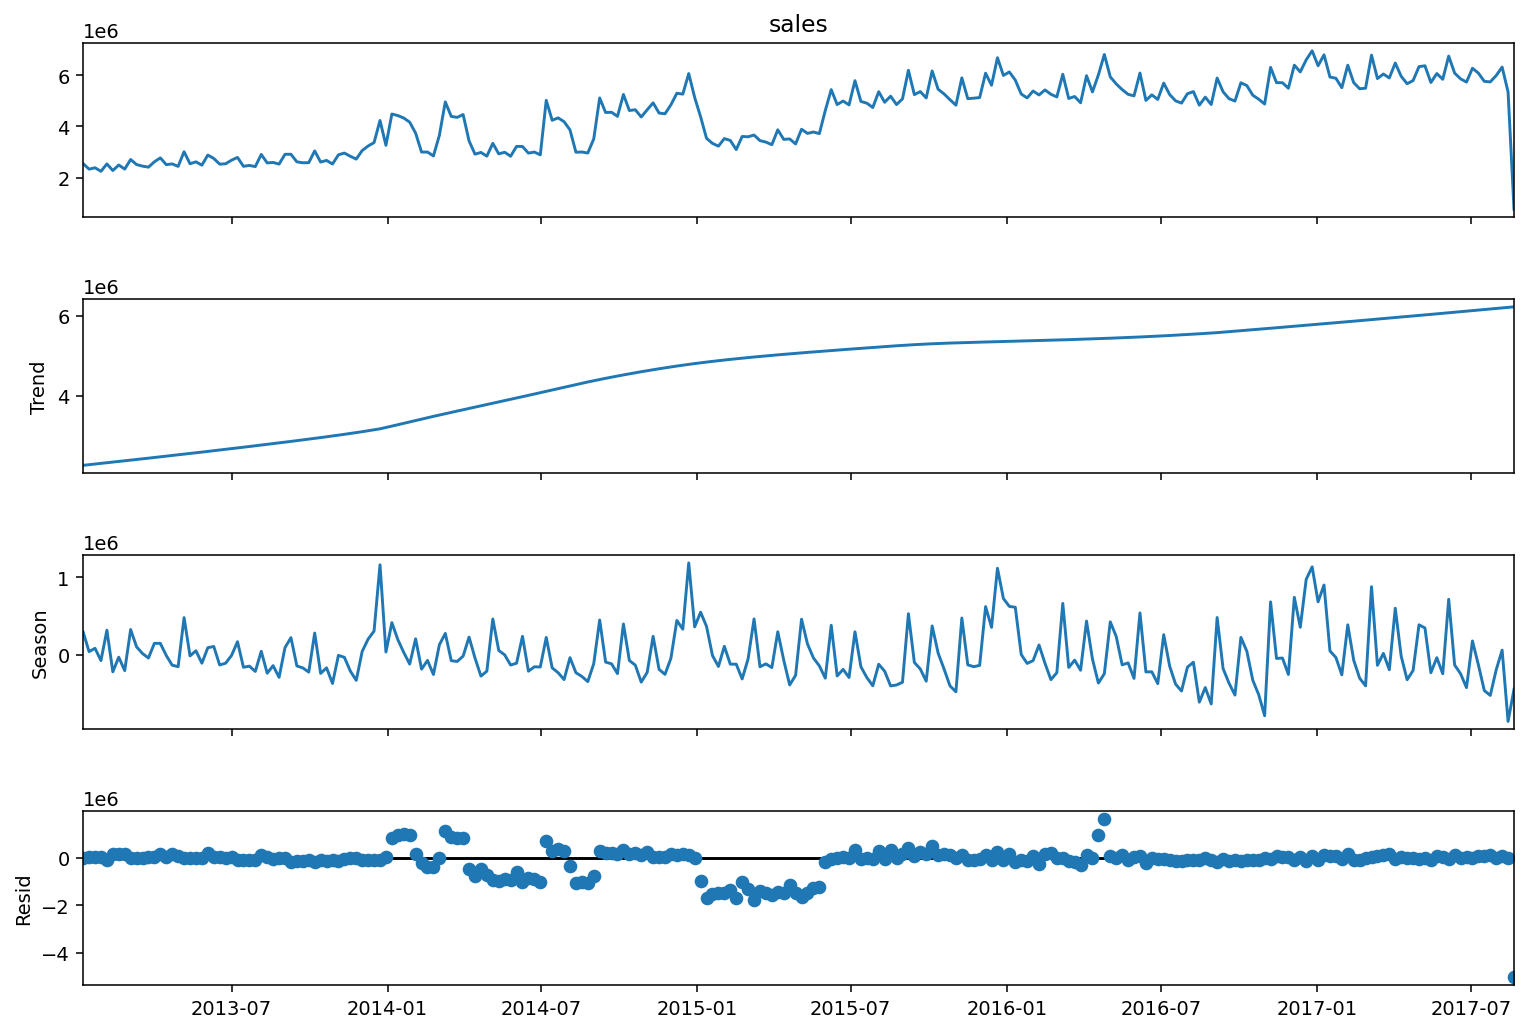

count    2.420000e+02
mean     4.436549e+06
std      1.343956e+06
min      7.626619e+05
25%      3.003618e+06
50%      4.845344e+06
75%      5.489619e+06
max      6.959313e+06
Name: sales, dtype: float64

In [7]:
daily_total = panel.groupby("date", observed=True)["sales"].sum().asfreq("D").fillna(0)
weekly_total = daily_total.resample("W-MON").sum()

fig, ax = plt.subplots(figsize=(11, 4))
daily_total.plot(ax=ax)
ax.set_title("Total Daily Sales")
ax.set_xlabel("Date")
ax.set_ylabel("Sales")
save_and_show(fig, FIGURE_DIR / "total_daily_sales.png")

fig, ax = plt.subplots(figsize=(11, 4))
weekly_total.plot(ax=ax)
ax.set_title("Total Weekly Sales")
ax.set_xlabel("Week")
ax.set_ylabel("Sales")
save_and_show(fig, FIGURE_DIR / "total_weekly_sales.png")

for name, values, period in [("daily_total", daily_total, 7), ("weekly_total", weekly_total, 52)]:
    decomposition = STL(values.astype(float), period=period, robust=True).fit()
    figure = decomposition.plot()
    figure.set_size_inches(12, 8)
    output_path = FIGURE_DIR / f"{name}_stl.png"
    figure.savefig(output_path, dpi=140, bbox_inches="tight")
    display_saved_image(output_path)
    plt.close(figure)

weekly_total.describe()

### ACF/PACF and Seasonal Lags

Daily lags inspect weekly repetition. Weekly lags inspect quarterly and annual behavior. Level-specific lag autocorrelations are also recorded.

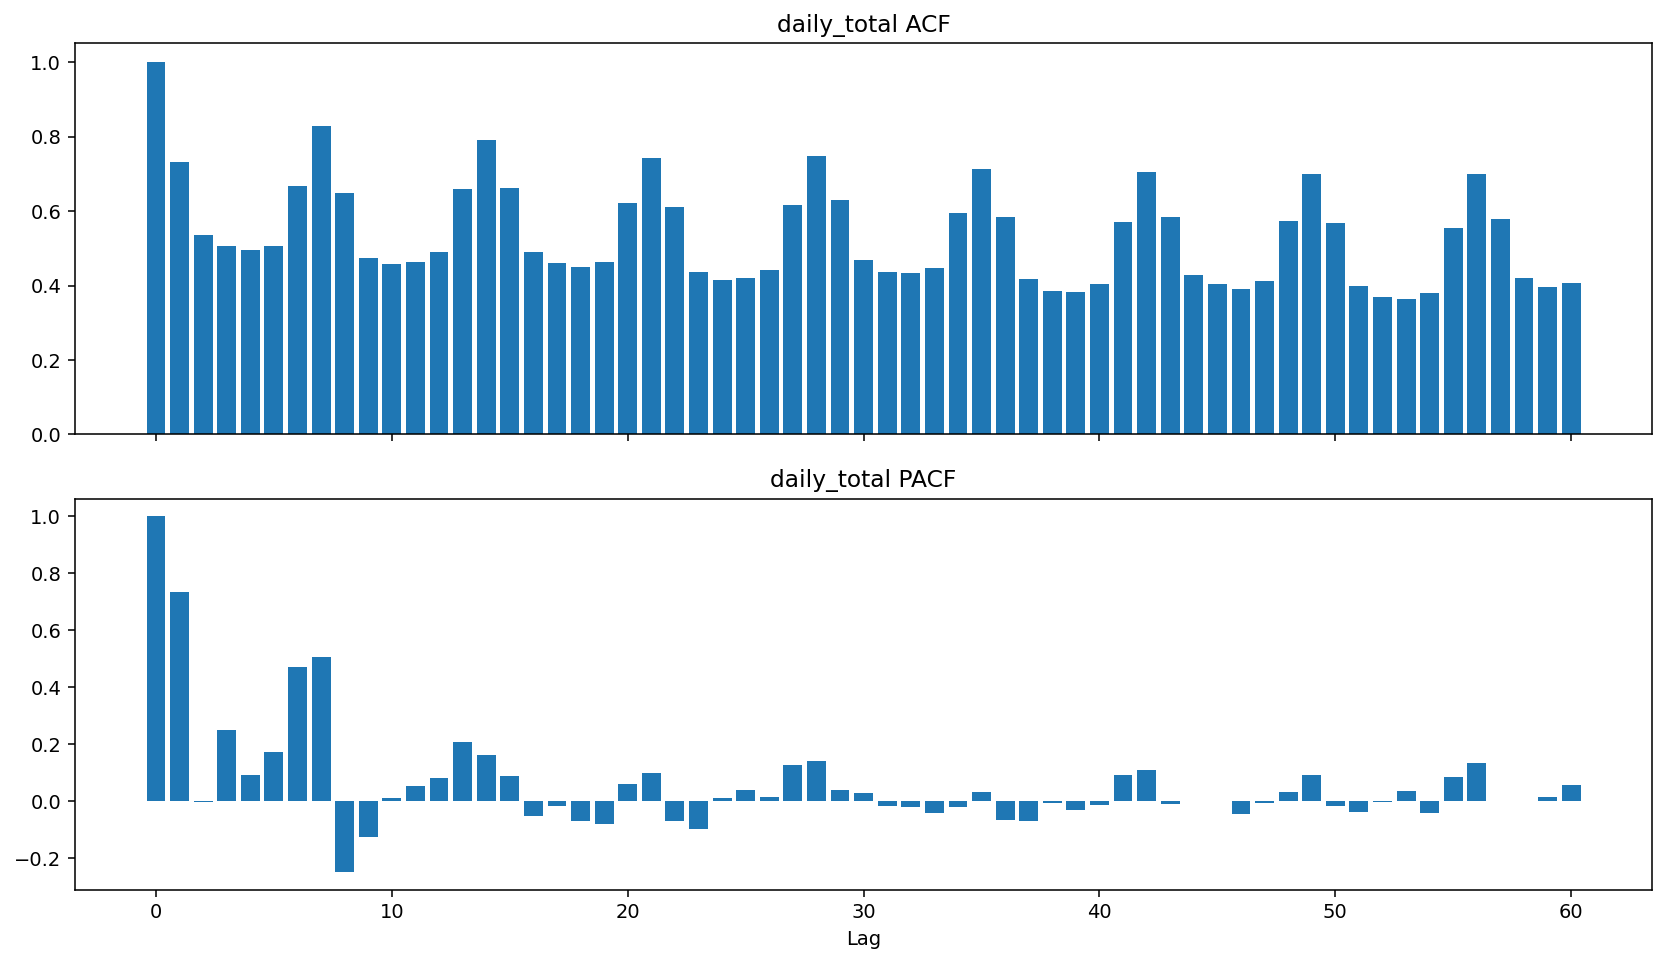

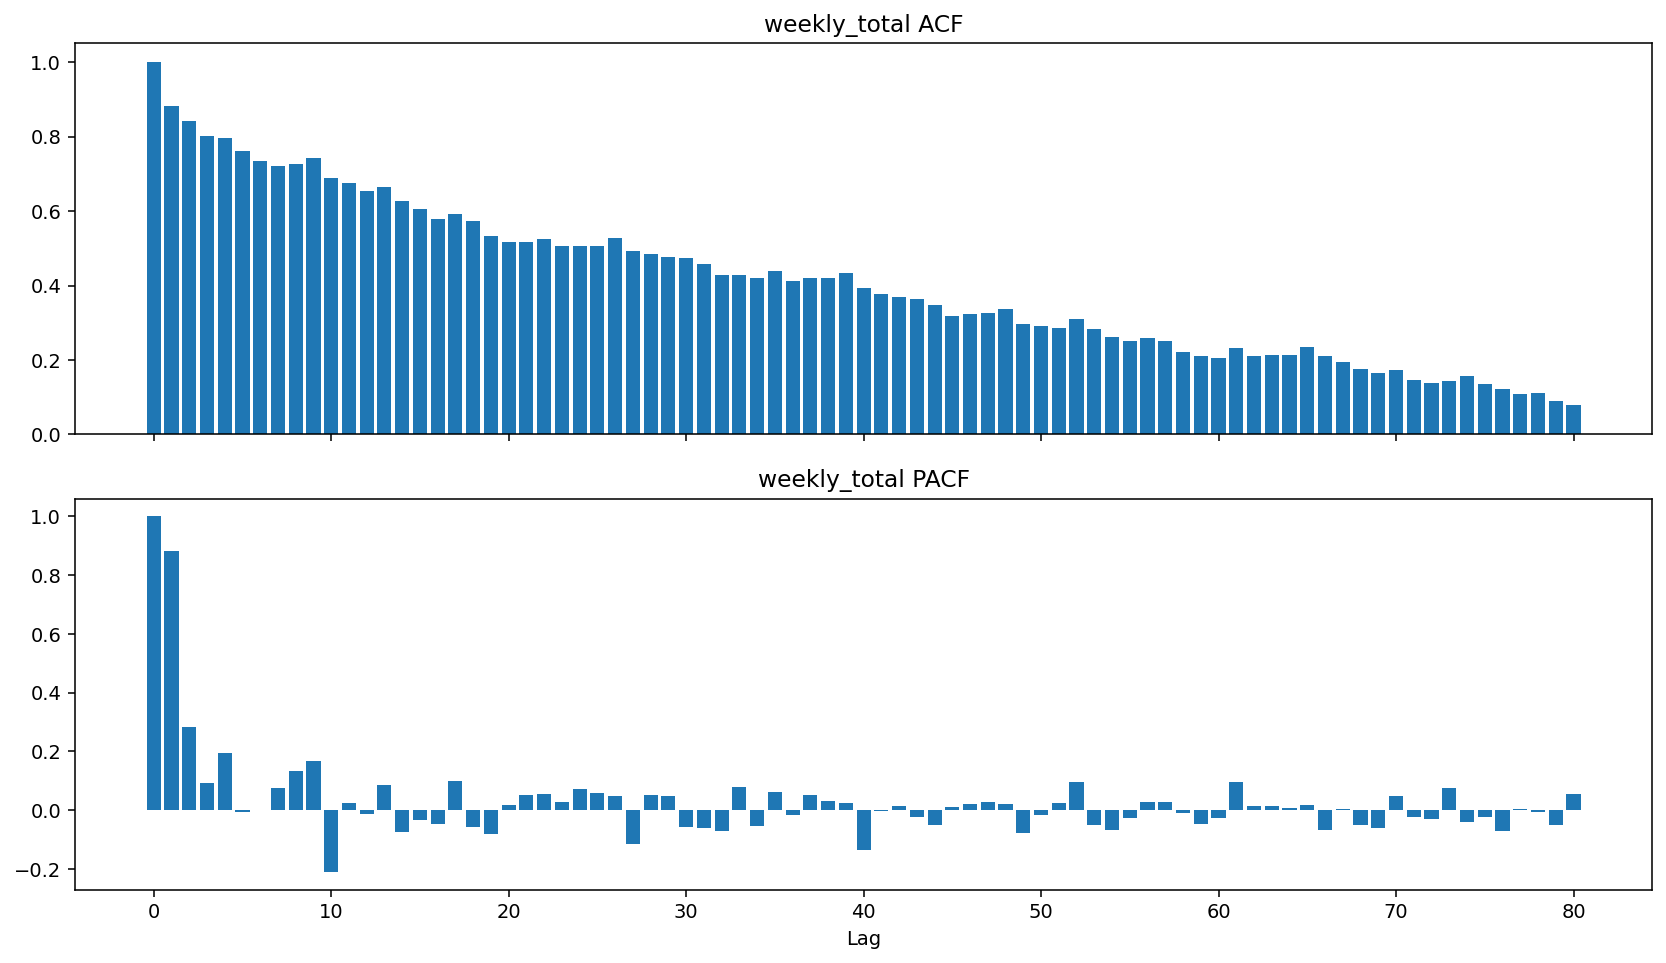

,series,kind,lag,value
1,daily_total,acf,1,0.732555
7,daily_total,acf,7,0.829415
14,daily_total,acf,14,0.791093
28,daily_total,acf,28,0.747827
52,daily_total,acf,52,0.369291
123,weekly_total,acf,1,0.882068
129,weekly_total,acf,7,0.720396
136,weekly_total,acf,14,0.627939
150,weekly_total,acf,28,0.484629
174,weekly_total,acf,52,0.311198


In [8]:
daily_acf = plot_acf_pacf("daily_total", daily_total, 60, FIGURE_DIR / "daily_total_acf_pacf.png")
weekly_acf = plot_acf_pacf("weekly_total", weekly_total, 80, FIGURE_DIR / "weekly_total_acf_pacf.png")
acf_pacf_values = pd.concat([daily_acf, weekly_acf], ignore_index=True)
acf_pacf_values.to_csv(TABLE_DIR / "acf_pacf_values.csv", index=False)
acf_pacf_values.loc[
    (acf_pacf_values["kind"] == "acf") & (acf_pacf_values["lag"].isin([1, 7, 14, 28, 52])),
    ["series", "kind", "lag", "value"],
]

In [9]:
seasonal_lag_rows = []
for keys, level in level_specs:
    daily = hierarchy_daily(joined, keys, level)
    for series_id, frame in daily.groupby("series_id", observed=True):
        values = frame.sort_values("date").set_index("date")["sales"].asfreq("D").fillna(0)
        seasonal_lag_rows.append(
            {
                "level": level,
                "series_id": series_id,
                "lag_7_autocorr": lag_autocorrelation(values, 7),
                "lag_14_autocorr": lag_autocorrelation(values, 14),
                "lag_28_autocorr": lag_autocorrelation(values, 28),
            }
        )
seasonal_lags = pd.DataFrame(seasonal_lag_rows)
seasonal_lags.to_csv(TABLE_DIR / "seasonal_lags_by_level_series.csv", index=False)
seasonal_lag_summary = (
    seasonal_lags.groupby("level", observed=True)[["lag_7_autocorr", "lag_14_autocorr", "lag_28_autocorr"]]
    .agg(["count", "mean", "median"])
)
seasonal_lag_summary.to_csv(TABLE_DIR / "seasonal_lags_by_level_summary.csv")
seasonal_lag_summary

lag_7_autocorr                     lag_14_autocorr            \
                      count      mean    median           count      mean   
level                                                                       
city                     22  0.713745  0.759170              22  0.660891   
cluster                  17  0.808701  0.800705              17  0.767240   
family                   33  0.739973  0.762056              33  0.659397   
state                    16  0.737275  0.768782              16  0.681524   
store                    54  0.695173  0.728426              54  0.649375   
store_family           1728  0.463793  0.464975            1728  0.409947   
total                     1  0.833246  0.833246               1  0.799722   

                       lag_28_autocorr                      
                median           count      mean    median  
level                                                       
city          0.697037              22  0.641001  0.640722  
cluster       0.762174              17  0.725126  0.718962  
family        0.703011              33  0.596460  0.634370  
state         0.704967              16  0.656101  0.676920  
store         0.687015              54  0.613435  0.640394  
store_family  0.400172            1727  0.365222  0.350639  
total         0.799722               1  0.765973  0.765973

### Stationarity

ADF and KPSS are run on representative high-volume series at each hierarchy level before and after first differencing.

In [10]:
stationarity_frames = []
for keys, level in level_specs:
    daily = hierarchy_daily(joined, keys, level)
    sample_limit = 1 if level == "total" else 5
    sample = stationarity_sample(daily, sample_limit)
    sample.insert(0, "level", level)
    stationarity_frames.append(sample)
stationarity_tests = pd.concat(stationarity_frames, ignore_index=True)
stationarity_tests.to_csv(TABLE_DIR / "stationarity_tests.csv", index=False)
stationarity_summary = stationarity_tests.assign(
    level_stationary_adf=stationarity_tests["adf_p"] < 0.05,
    level_stationary_kpss=stationarity_tests["kpss_p"] >= 0.05,
    diff_stationary_adf=stationarity_tests["diff_adf_p"] < 0.05,
    diff_stationary_kpss=stationarity_tests["diff_kpss_p"] >= 0.05,
).groupby("level", observed=True)[[
    "level_stationary_adf",
    "level_stationary_kpss",
    "diff_stationary_adf",
    "diff_stationary_kpss",
]].mean().reset_index()
stationarity_summary.to_csv(TABLE_DIR / "stationarity_summary_by_level.csv", index=False)
stationarity_summary

,level,level_stationary_adf,level_stationary_kpss,diff_stationary_adf,diff_stationary_kpss
0,city,0.2,0.0,1.0,1.0
1,cluster,0.2,0.0,1.0,1.0
2,family,0.6,0.0,1.0,1.0
3,state,0.2,0.0,1.0,1.0
4,store,0.6,0.0,1.0,1.0
5,store_family,1.0,0.0,1.0,1.0
6,total,0.0,0.0,1.0,1.0


### Seasonality Strength by Intermittency Segment

Lag-7 autocorrelation is measured per bottom series and summarized by intermittency segment.

In [11]:
segment_lookup = series_inventory[["store_nbr", "family", "intermittency_segment"]]
lag7_rows = []
for (store_nbr, family), frame in panel.groupby(["store_nbr", "family"], observed=True):
    values = frame.sort_values("date").set_index("date")["sales"].asfreq("D").fillna(0)
    lag7_rows.append({"store_nbr": store_nbr, "family": family, "lag7_autocorr": lag_autocorrelation(values, 7)})
lag7_by_series = pd.DataFrame(lag7_rows).merge(segment_lookup, on=["store_nbr", "family"], how="left")
lag7_summary = (
    lag7_by_series.groupby("intermittency_segment", observed=True)["lag7_autocorr"]
    .agg(["count", "mean", "median"])
    .reset_index()
)
lag7_by_series.to_csv(TABLE_DIR / "lag7_autocorr_by_series.csv", index=False)
lag7_summary.to_csv(TABLE_DIR / "weekly_seasonality_by_segment.csv", index=False)
lag7_summary

,intermittency_segment,count,mean,median
0,erratic,371,0.393492,0.376027
1,intermittent,226,0.218853,0.151309
2,lumpy,188,0.341651,0.345190
3,smooth,943,0.574503,0.605584


### Outliers and Closures

This catalogs dates with total-demand outliers and dates where many stores report zero demand.

In [12]:
rolling_median = daily_total.rolling(28, center=True, min_periods=14).median()
residual = daily_total - rolling_median
mad = (residual - residual.median()).abs().median()
robust_z = 0.6745 * (residual - residual.median()) / mad

total_outlier_dates = pd.DataFrame(
    {"date": daily_total.index, "sales": daily_total.values, "robust_z": robust_z.values}
).dropna()
total_outlier_dates = total_outlier_dates.loc[total_outlier_dates["robust_z"].abs() >= 6].sort_values(
    "robust_z", key=lambda column: column.abs(), ascending=False
)
total_outlier_dates.to_csv(TABLE_DIR / "total_outlier_dates.csv", index=False)

store_daily = joined.groupby(["store_nbr", "date"], observed=True, as_index=False)["sales"].sum()
store_level_zero_days = (
    store_daily.loc[store_daily["sales"] == 0]
    .groupby("date")
    .size()
    .sort_values(ascending=False)
    .head(30)
    .reset_index(name="stores_zero")
)
store_level_zero_days.to_csv(TABLE_DIR / "store_level_zero_days_top30.csv", index=False)

christmas_rows = daily_total.loc[daily_total.index.strftime("%m-%d") == "12-25"]
print("Christmas total rows after P0 reindex:")
print(christmas_rows)
print("Top store-level zero dates:")
store_level_zero_days.head(10)

Christmas total rows after P0 reindex:
date
2013-12-25    0.0
2014-12-25    0.0
2015-12-25    0.0
2016-12-25    0.0
Name: sales, dtype: float64
Top store-level zero dates:


,date,stores_zero
0,2016-12-25,53
1,2015-12-25,53
2,2017-01-01,52
3,2016-01-01,52
4,2014-12-25,48
5,2015-01-01,47
6,2013-12-25,47
7,2014-01-01,45
8,2016-09-22,2
9,2016-09-24,2


### Demand Distribution and Variance Profile

Bottom demand is checked for zero inflation, skew, and high outliers. Variance by hierarchy level shows how aggregation reduces noise.

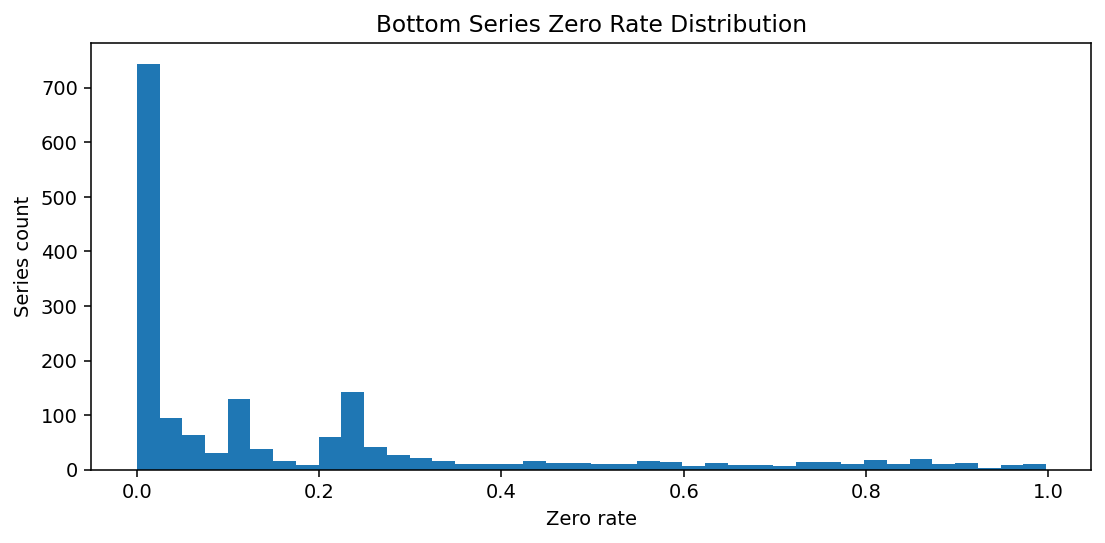

(                metric          value
 0     bottom_zero_rate       0.158638
 1    bottom_mean_sales     438.133015
 2  bottom_median_sales      32.000000
 3     bottom_p95_sales    2365.954400
 4     bottom_p99_sales    6077.620830
 5     bottom_max_sales  124717.000000,
           level  mean_variance  median_variance
 0         total   5.577938e+10     5.577938e+10
 1         state   1.224167e+09     3.578958e+07
 2          city   8.115843e+08     1.779904e+07
 3         store   3.497585e+07     1.810100e+07
 4       cluster   3.241146e+08     1.478644e+08
 5        family   3.769596e+08     5.086125e+05
 6  store_family   2.871189e+05     5.954443e+02)

In [13]:
demand_distribution = pd.DataFrame(
    {
        "metric": [
            "bottom_zero_rate",
            "bottom_mean_sales",
            "bottom_median_sales",
            "bottom_p95_sales",
            "bottom_p99_sales",
            "bottom_max_sales",
        ],
        "value": [
            float((panel["sales"] == 0).mean()),
            float(panel["sales"].mean()),
            float(panel["sales"].median()),
            float(panel["sales"].quantile(0.95)),
            float(panel["sales"].quantile(0.99)),
            float(panel["sales"].max()),
        ],
    }
)
demand_distribution.to_csv(TABLE_DIR / "demand_distribution_summary.csv", index=False)

variance_rows = []
for keys, level in level_specs:
    daily = hierarchy_daily(joined, keys, level)
    per_series = daily.groupby("series_id", observed=True)["sales"].var()
    variance_rows.append(
        {
            "level": level,
            "mean_variance": float(per_series.mean()),
            "median_variance": float(per_series.median()),
        }
    )
variance_profile = pd.DataFrame(variance_rows)
variance_profile.to_csv(TABLE_DIR / "variance_profile_by_level.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(series_inventory["zero_rate"], bins=40)
ax.set_title("Bottom Series Zero Rate Distribution")
ax.set_xlabel("Zero rate")
ax.set_ylabel("Series count")
save_and_show(fig, FIGURE_DIR / "bottom_zero_rate_distribution.png")

demand_distribution, variance_profile

### P1 Interim Findings and Open Questions for P2

**What the current P1 run produced**

- Active bottom series after P0: 1,729 store-family series.
- Post-launch history length: min 37 days, median 1,686 days, max 1,688 days.
- Bottom-level zero rate after P0 truncation: 15.86% across panel rows.
- Series inactive in the final 90 days: 31.
- Intermittency segments: 943 smooth, 371 erratic, 227 intermittent, 188 lumpy.
- Zero rate by hierarchy level supports the constitution's broad assignment: total/state/city/store/cluster are under 1%, family is 6.0%, and bottom store-family is 15.9% after truncation.
- Lag-7 autocorrelation is strongest for smooth series: median 0.606. Intermittent series have much weaker weekly structure: median 0.151.
- Stationarity tests indicate non-stationary levels for most aggregates and much stronger stationarity after first differencing.
- Closure/outlier catalog confirms Christmas rows are zero after P0 reindexing: 2013-12-25, 2014-12-25, 2015-12-25, 2016-12-25. New Year's Day also appears as a major low-demand closure/outlier.
- Demand remains strongly skewed at the bottom level: median daily sales 32, p95 2,365.952, p99 6,077.617, max 124,717.

**Artifacts written by the notebook run**

- Tables: `outputs/metrics/p1_ts_eda/`
- Figures: `outputs/figures/p1_ts_eda/`

**P1 exit criteria status**

- Every series assigned to an intermittency segment: done in `series_inventory.csv` and `intermittency_segments.csv`.
- Seasonal lags identified per level with evidence: done in `seasonal_lags_by_level_series.csv`, `seasonal_lags_by_level_summary.csv`, and ACF/PACF figures.
- Stationarity result recorded per level: done for high-volume samples at every level in `stationarity_tests.csv` and `stationarity_summary_by_level.csv`.
- Outlier and closure dates catalogued: done in `total_outlier_dates.csv` and `store_level_zero_days_top30.csv`.
- Grain decision: weekly grain remains supported by strong weekly structure, closure spikes, and the need to avoid quarter-ahead daily noise.
- Model-to-level assignment: broadly supported by the zero-rate profile and segment seasonality table.

**Open questions for P2**

- Which families and stores have the strongest promotion response, and is the response large enough to justify promo features?
- Do transferred holidays behave like normal days, and does the transfer row carry the effect?
- Does oil correlate with demand at any lag after aggregation, or is it mostly a weak macro regressor?
- Are transactions a useful leading signal, or mainly contemporaneous/collinear with sales?
- Do store type, cluster, city, or state explain demand shape enough to justify encodings?

## P2 · Supporting EDA

This section answers only the open questions raised by P1. It measures relationships for candidate exogenous variables and store attributes; it does not build feature columns for modelling.

In [14]:
OIL_PATH = PROJECT_ROOT / "data" / "raw" / "favorita" / "oil.csv"
HOLIDAYS_PATH = PROJECT_ROOT / "data" / "raw" / "favorita" / "holidays_events.csv"
TRANSACTIONS_PATH = PROJECT_ROOT / "data" / "raw" / "favorita" / "transactions.csv"
P2_FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures" / "p2_supporting_eda"
P2_TABLE_DIR = PROJECT_ROOT / "outputs" / "metrics" / "p2_supporting_eda"
P2_FIGURE_DIR.mkdir(parents=True, exist_ok=True)
P2_TABLE_DIR.mkdir(parents=True, exist_ok=True)

oil = pd.read_csv(OIL_PATH, parse_dates=["date"])
holidays = pd.read_csv(HOLIDAYS_PATH, parse_dates=["date"])
transactions = pd.read_csv(TRANSACTIONS_PATH, parse_dates=["date"])

p2_panel = panel.copy()
p2_panel["promo_flag"] = p2_panel["onpromotion"] > 0
store_daily = (
    p2_panel.groupby(["store_nbr", "date"], observed=True)
    .agg(sales=("sales", "sum"), onpromotion=("onpromotion", "sum"))
    .reset_index()
    .merge(stores, on="store_nbr", how="left")
)
store_daily["dow"] = store_daily["date"].dt.dayofweek
store_daily["store_dow_median"] = store_daily.groupby(["store_nbr", "dow"], observed=True)["sales"].transform("median")
store_daily["sales_index"] = store_daily["sales"] / store_daily["store_dow_median"].replace(0, np.nan)

pd.DataFrame(
    {
        "table": ["oil", "holidays_events", "transactions"],
        "rows": [len(oil), len(holidays), len(transactions)],
        "min_date": [oil["date"].min().date(), holidays["date"].min().date(), transactions["date"].min().date()],
        "max_date": [oil["date"].max().date(), holidays["date"].max().date(), transactions["date"].max().date()],
    }
)

,table,rows,min_date,max_date
0,oil,1218,2013-01-01,2017-08-31
1,holidays_events,350,2012-03-02,2017-12-26
2,transactions,83488,2013-01-01,2017-08-15


### Promotion Response

Promotion response is measured as observed sales lift on promoted rows versus non-promoted rows. This is association, not a causal estimate, but it is enough for P2 to decide whether promotion deserves candidate features in P3.

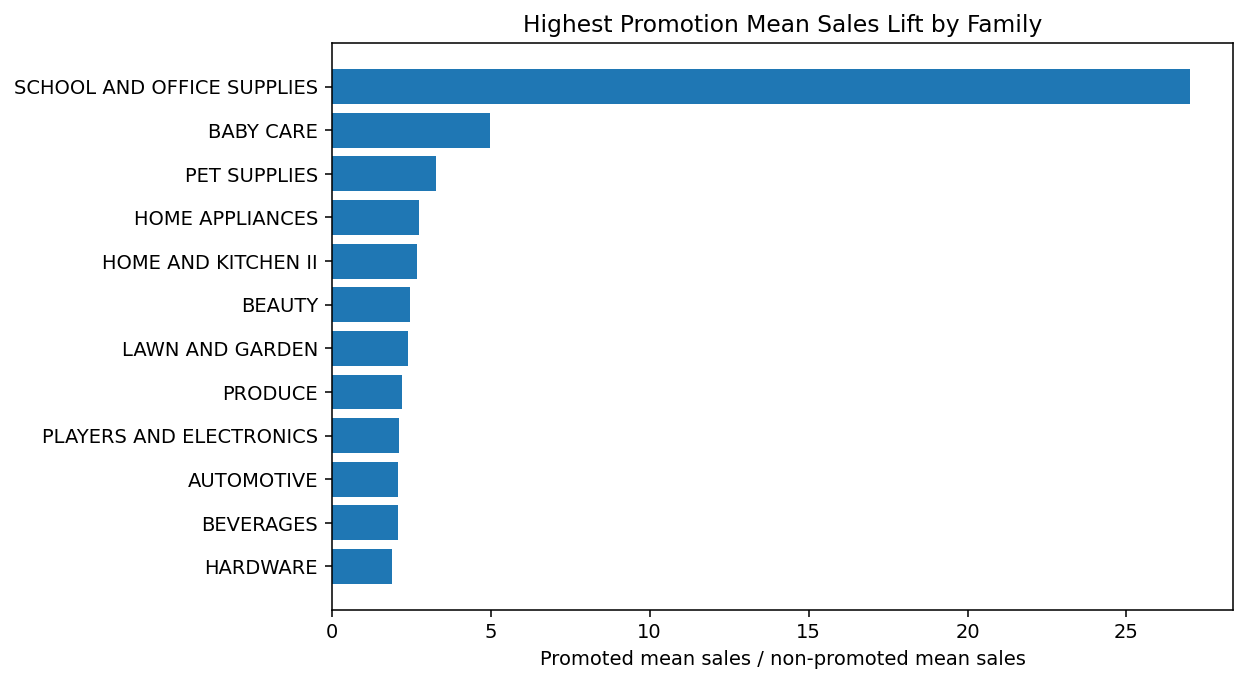

(              metric     value
 0    promo_row_share  0.249471
 1  promo_sales_share  0.647798,
                         family  nonpromo_mean_sales  promo_mean_sales  \
 31  SCHOOL AND OFFICE SUPPLIES             1.648779         44.529107   
 1                    BABY CARE             0.332499          1.660377   
 26                PET SUPPLIES             4.817514         15.835244   
 17             HOME APPLIANCES             0.506885          1.396552   
 16         HOME AND KITCHEN II            15.287292         41.158133   
 2                       BEAUTY             3.353107          8.291266   
 20             LAWN AND GARDEN             7.027711         16.786862   
 30                     PRODUCE          1097.264448       2438.220197   
 27     PLAYERS AND ELECTRONICS             8.262193         17.363958   
 0                   AUTOMOTIVE             6.322905         13.241978   
 
     nonpromo_median_sales  promo_median_sales  nonpromo_rows  promo_rows  \
 31       

In [15]:
promo_overall = pd.DataFrame(
    {
        "metric": ["promo_row_share", "promo_sales_share"],
        "value": [
            float(p2_panel["promo_flag"].mean()),
            float(p2_panel.loc[p2_panel["promo_flag"], "sales"].sum() / p2_panel["sales"].sum()),
        ],
    }
)

promo_family_long = (
    p2_panel.groupby(["family", "promo_flag"], observed=True)
    .agg(mean_sales=("sales", "mean"), median_sales=("sales", "median"), rows=("sales", "size"))
    .reset_index()
)
promo_family_mean = promo_family_long.pivot(index="family", columns="promo_flag", values="mean_sales")
promo_family_median = promo_family_long.pivot(index="family", columns="promo_flag", values="median_sales")
promo_family_rows = promo_family_long.pivot(index="family", columns="promo_flag", values="rows")
promo_family = pd.DataFrame(
    {
        "family": promo_family_mean.index,
        "nonpromo_mean_sales": promo_family_mean.get(False),
        "promo_mean_sales": promo_family_mean.get(True),
        "nonpromo_median_sales": promo_family_median.get(False),
        "promo_median_sales": promo_family_median.get(True),
        "nonpromo_rows": promo_family_rows.get(False),
        "promo_rows": promo_family_rows.get(True),
    }
).reset_index(drop=True)
promo_family["mean_lift"] = promo_family["promo_mean_sales"] / promo_family["nonpromo_mean_sales"].replace(0, np.nan)
promo_family["median_lift"] = promo_family["promo_median_sales"] / promo_family["nonpromo_median_sales"].replace(0, np.nan)
promo_family = promo_family.sort_values("mean_lift", ascending=False)

promo_store = (
    p2_panel.groupby(["store_nbr", "promo_flag"], observed=True)["sales"]
    .mean()
    .unstack("promo_flag")
    .rename(columns={False: "nonpromo_mean_sales", True: "promo_mean_sales"})
    .reset_index()
)
promo_store["mean_lift"] = promo_store["promo_mean_sales"] / promo_store["nonpromo_mean_sales"].replace(0, np.nan)
promo_store = promo_store.merge(stores, on="store_nbr", how="left").sort_values("mean_lift", ascending=False)

promo_overall.to_csv(P2_TABLE_DIR / "promotion_overall.csv", index=False)
promo_family.to_csv(P2_TABLE_DIR / "promotion_lift_by_family.csv", index=False)
promo_store.to_csv(P2_TABLE_DIR / "promotion_lift_by_store.csv", index=False)

fig, ax = plt.subplots(figsize=(9, 5))
plot_data = promo_family.dropna(subset=["mean_lift"]).head(12).sort_values("mean_lift")
ax.barh(plot_data["family"], plot_data["mean_lift"])
ax.set_title("Highest Promotion Mean Sales Lift by Family")
ax.set_xlabel("Promoted mean sales / non-promoted mean sales")
save_and_show(fig, P2_FIGURE_DIR / "promotion_lift_by_family.png")

promo_overall, promo_family.head(10), promo_store.head(10)

### Holiday Effects

Transferred holiday behavior is checked directly. A `Holiday` row with `transferred=True` should behave close to a normal comparable weekday; the effect should sit on the corresponding `Transfer` row.

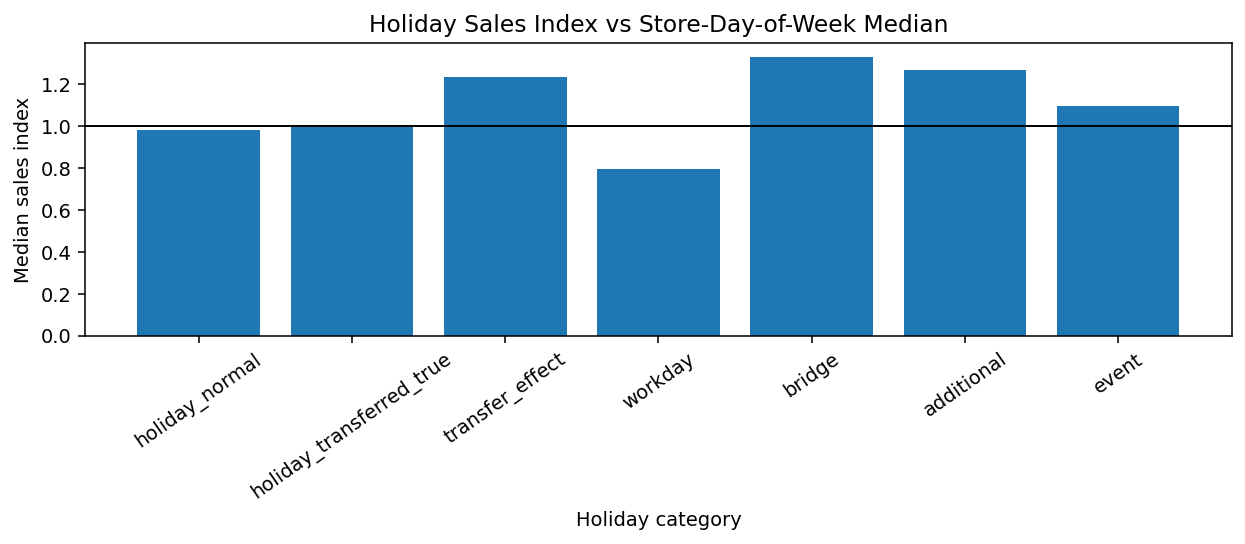

,category,holiday_dates,store_date_rows,median_sales_index,mean_sales_index
0,holiday_normal,190,7452,0.983499,0.980979
1,holiday_transferred_true,12,468,1.006156,0.957252
2,transfer_effect,12,468,1.235695,1.323309
3,workday,5,241,0.794551,0.872216
4,bridge,5,149,1.327978,1.393280
5,additional,51,1914,1.267111,1.389992
6,event,55,2821,1.094520,1.129268


In [16]:
normal_holiday_dates = set(holidays.loc[(holidays["type"] == "Holiday") & (~holidays["transferred"]), "date"])
transferred_true_dates = set(holidays.loc[(holidays["type"] == "Holiday") & (holidays["transferred"]), "date"])
transfer_effect_dates = set(holidays.loc[holidays["type"] == "Transfer", "date"])
workday_dates = set(holidays.loc[holidays["type"] == "Work Day", "date"])
bridge_dates = set(holidays.loc[holidays["type"] == "Bridge", "date"])
additional_dates = set(holidays.loc[holidays["type"] == "Additional", "date"])
event_dates = set(holidays.loc[holidays["type"] == "Event", "date"])

holiday_categories = [
    ("holiday_normal", normal_holiday_dates),
    ("holiday_transferred_true", transferred_true_dates),
    ("transfer_effect", transfer_effect_dates),
    ("workday", workday_dates),
    ("bridge", bridge_dates),
    ("additional", additional_dates),
    ("event", event_dates),
]
holiday_rows = []
for label, dates in holiday_categories:
    matched = store_daily.loc[store_daily["date"].isin(dates)]
    holiday_rows.append(
        {
            "category": label,
            "holiday_dates": len(dates),
            "store_date_rows": len(matched),
            "median_sales_index": float(matched["sales_index"].median()),
            "mean_sales_index": float(matched["sales_index"].mean()),
        }
    )
holiday_effects = pd.DataFrame(holiday_rows)
holiday_effects.to_csv(P2_TABLE_DIR / "holiday_effects_by_type.csv", index=False)
holidays.to_csv(P2_TABLE_DIR / "holiday_raw_catalog.csv", index=False)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(holiday_effects["category"], holiday_effects["median_sales_index"])
ax.axhline(1.0, color="black", linewidth=1)
ax.set_title("Holiday Sales Index vs Store-Day-of-Week Median")
ax.set_xlabel("Holiday category")
ax.set_ylabel("Median sales index")
ax.tick_params(axis="x", rotation=35)
save_and_show(fig, P2_FIGURE_DIR / "holiday_sales_index.png")

holiday_effects

### Oil Relationship

Oil is checked at weekly grain using percent changes and lags from 0 to 8 weeks. A weak correlation here does not ban oil from later upper-level models, but it lowers its priority as an explanatory feature.

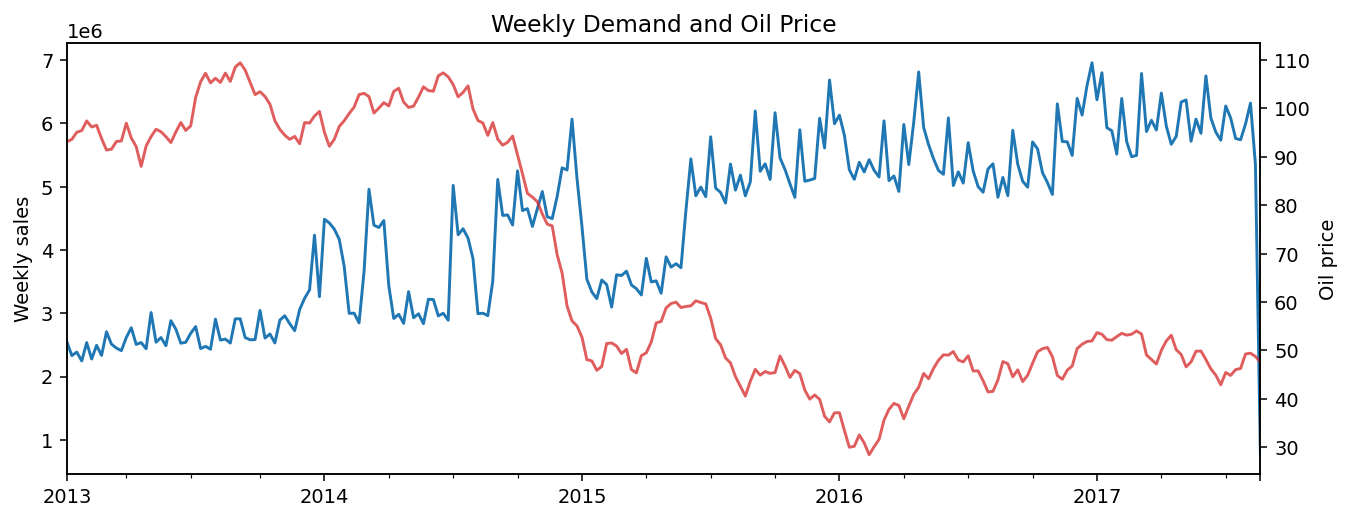

,oil_lag_weeks,corr_sales_change_vs_oil_change
0,0,0.033401
1,1,0.031542
2,2,0.014462
3,3,-0.059116
4,4,0.069751
5,5,0.085104
6,6,-0.024836
7,7,-0.031918
8,8,-0.031040


In [17]:
full_dates = pd.date_range(p2_panel["date"].min(), p2_panel["date"].max(), freq="D")
oil_daily = oil.set_index("date").reindex(full_dates).ffill().bfill().rename_axis("date").reset_index()
daily_total_p2 = p2_panel.groupby("date", observed=True)["sales"].sum().reindex(full_dates, fill_value=0)
weekly_oil_sales = daily_total_p2.resample("W-MON").sum().to_frame("sales")
weekly_oil_sales["oil"] = oil_daily.set_index("date")["dcoilwtico"].resample("W-MON").mean()
weekly_oil_sales["sales_change"] = weekly_oil_sales["sales"].pct_change()
weekly_oil_sales["oil_change"] = weekly_oil_sales["oil"].pct_change()

oil_lag_correlations = pd.DataFrame(
    {
        "oil_lag_weeks": list(range(0, 9)),
        "corr_sales_change_vs_oil_change": [
            float(weekly_oil_sales["sales_change"].corr(weekly_oil_sales["oil_change"].shift(lag))) for lag in range(0, 9)
        ],
    }
)
oil_lag_correlations.to_csv(P2_TABLE_DIR / "oil_lag_correlations.csv", index=False)

fig, ax1 = plt.subplots(figsize=(11, 4))
weekly_oil_sales["sales"].plot(ax=ax1, color="tab:blue", label="Weekly sales")
ax1.set_ylabel("Weekly sales")
ax2 = ax1.twinx()
weekly_oil_sales["oil"].plot(ax=ax2, color="tab:red", alpha=0.75, label="Oil")
ax2.set_ylabel("Oil price")
ax1.set_title("Weekly Demand and Oil Price")
fig.savefig(P2_FIGURE_DIR / "weekly_sales_and_oil.png", dpi=140, bbox_inches="tight")
display_saved_image(P2_FIGURE_DIR / "weekly_sales_and_oil.png")
plt.close(fig)

oil_lag_correlations

### Transactions Relationship

Transactions are store footfall. They are strongly associated with same-day sales, but same-day transactions are not known at forecast origin. Lag checks determine whether they are useful as historical demand-shape signals rather than future regressors.

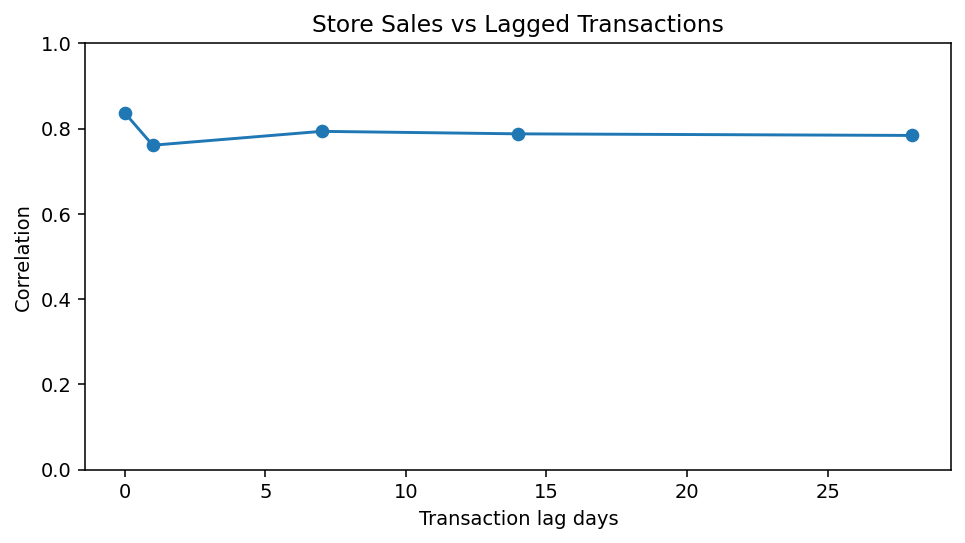

(                              metric         value
 0        transaction_store_date_rows  83488.000000
 1              panel_store_date_rows  84408.000000
 2  transaction_null_share_after_join      0.010899,
    transactions_lag_days  corr_sales_vs_transactions_lag  non_null_rows
 0                      0                        0.837384          83488
 1                      1                        0.761216          83434
 2                      7                        0.793771          83110
 3                     14                        0.787923          82732
 4                     28                        0.784170          81976)

In [18]:
sales_transactions = store_daily.merge(transactions, on=["store_nbr", "date"], how="left").sort_values(["store_nbr", "date"])
transaction_rows = []
for lag in [0, 1, 7, 14, 28]:
    lagged = sales_transactions.copy()
    lagged["transactions_lag"] = lagged.groupby("store_nbr", observed=True)["transactions"].shift(lag)
    transaction_rows.append(
        {
            "transactions_lag_days": lag,
            "corr_sales_vs_transactions_lag": float(lagged["sales"].corr(lagged["transactions_lag"])),
            "non_null_rows": int(lagged["transactions_lag"].notna().sum()),
        }
    )
transaction_lag_correlations = pd.DataFrame(transaction_rows)
transaction_summary = pd.DataFrame(
    {
        "metric": ["transaction_store_date_rows", "panel_store_date_rows", "transaction_null_share_after_join"],
        "value": [len(transactions), len(sales_transactions), float(sales_transactions["transactions"].isna().mean())],
    }
)
transaction_lag_correlations.to_csv(P2_TABLE_DIR / "transaction_lag_correlations.csv", index=False)
transaction_summary.to_csv(P2_TABLE_DIR / "transaction_summary.csv", index=False)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(transaction_lag_correlations["transactions_lag_days"], transaction_lag_correlations["corr_sales_vs_transactions_lag"], marker="o")
ax.set_title("Store Sales vs Lagged Transactions")
ax.set_xlabel("Transaction lag days")
ax.set_ylabel("Correlation")
ax.set_ylim(0, 1)
save_and_show(fig, P2_FIGURE_DIR / "transaction_lag_correlations.png")

transaction_summary, transaction_lag_correlations

### Store Attributes and Demand Shape

Store type, cluster, city, and state are checked against P1 series-level demand shape. These attributes can support categorical encodings if they explain meaningful differences in scale, zero rate, or intermittency mix.

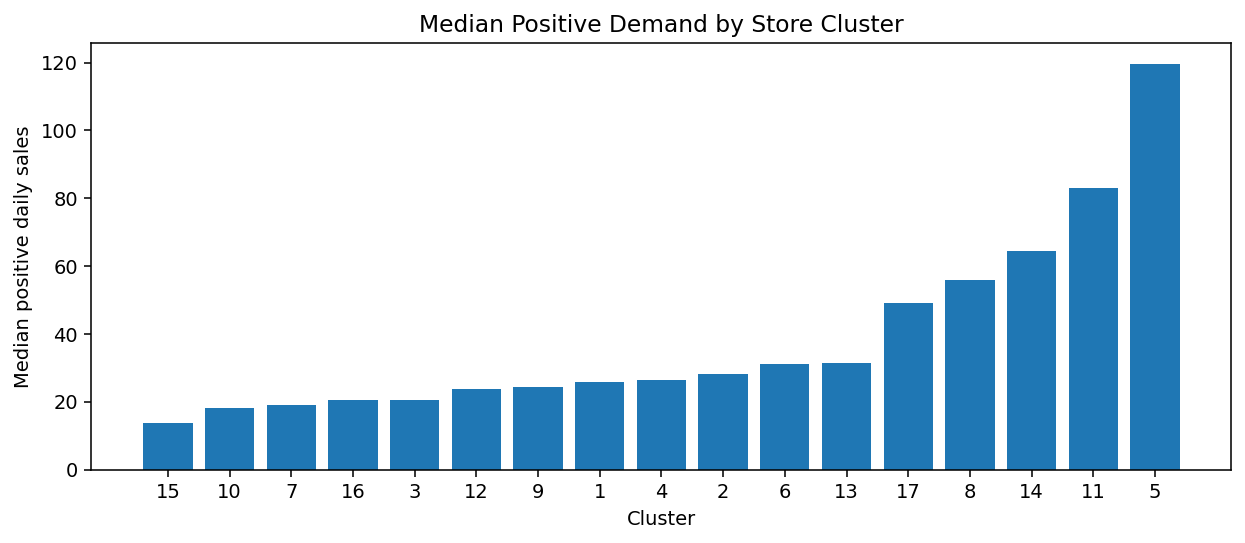

,attribute,attribute_value,series_count,median_zero_rate,median_positive_mean,lumpy_share,intermittent_share
36,city,Manta,64,0.005106,55.919492,0.078125,0.078125
22,city,Ambato,64,0.070021,48.113607,0.093750,0.140625
40,city,Quito,582,0.045940,47.199850,0.079038,0.103093
39,city,Quevedo,31,0.118003,37.277546,0.193548,0.161290
34,city,Loja,33,0.043990,28.868110,0.060606,0.090909
25,city,Cuenca,98,0.011559,28.667279,0.051020,0.102041
43,city,Santo Domingo,96,0.024867,27.956377,0.072917,0.177083
38,city,Puyo,32,0.014032,27.579031,0.156250,0.093750
35,city,Machala,64,0.064056,27.099027,0.125000,0.140625
24,city,Cayambe,32,0.046236,27.019297,0.093750,0.125000


In [19]:
series_inventory_p2 = pd.read_csv(TABLE_DIR / "series_inventory.csv").merge(stores, on="store_nbr", how="left")
attribute_frames = []
for attribute in ["type", "cluster", "city", "state"]:
    frame = (
        series_inventory_p2.groupby(attribute, observed=True)
        .agg(
            series_count=("family", "size"),
            median_zero_rate=("zero_rate", "median"),
            median_positive_mean=("positive_mean", "median"),
            lumpy_share=("intermittency_segment", lambda x: float((x == "lumpy").mean())),
            intermittent_share=("intermittency_segment", lambda x: float((x == "intermittent").mean())),
        )
        .reset_index()
        .rename(columns={attribute: "attribute_value"})
    )
    frame.insert(0, "attribute", attribute)
    attribute_frames.append(frame)
store_attribute_shape = pd.concat(attribute_frames, ignore_index=True)
store_attribute_shape.to_csv(P2_TABLE_DIR / "store_attribute_demand_shape.csv", index=False)

cluster_plot = store_attribute_shape.loc[store_attribute_shape["attribute"] == "cluster"].sort_values("median_positive_mean")
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(cluster_plot["attribute_value"].astype(str), cluster_plot["median_positive_mean"])
ax.set_title("Median Positive Demand by Store Cluster")
ax.set_xlabel("Cluster")
ax.set_ylabel("Median positive daily sales")
save_and_show(fig, P2_FIGURE_DIR / "store_cluster_positive_demand.png")

store_attribute_shape.sort_values(["attribute", "median_positive_mean"], ascending=[True, False]).head(20)

### P2 Findings and Feature Candidates for P3

**Answers to P1 open questions**

- Promotion response is large enough to justify promo features. Promoted rows are about one quarter of panel rows but carry almost two thirds of sales, and lift varies sharply by family and store.
- Transferred holidays behave like normal days in this run: the median sales index on `transferred=True` holiday rows is close to 1.0. `Transfer` rows carry the visible effect and should be represented separately from ordinary holidays.
- Oil has weak weekly change correlations across lags 0-8. It remains a low-priority upper-level candidate because the constitution expects it as real exogenous context, but P2 does not show a strong standalone relationship.
- Transactions are highly correlated with same-day sales and still correlated at short lags. Same-day transactions are not a valid future regressor at forecast origin, so use only lagged/rolling historical transaction signals if P3 includes them.
- Store type, cluster, city, and state show demand-shape differences. Cluster and geography can justify categorical encodings; they should not be treated as causal effects.

**Feature candidates for P3**

- Promotion: current known promotion count/flag, promotion lags, and shifted rolling promotion intensity.
- Holidays: separate normal holiday, transferred-original-day, transfer-effect, bridge, work-day, additional, and event indicators with locale-aware matching.
- Oil: forward-filled oil level and lagged oil changes at weekly grain, used cautiously.
- Transactions: lagged and shifted rolling transaction summaries only; never same-day future transactions.
- Store attributes: store type, cluster, city, and state encodings.

**P2 exit criteria status**

- Every open question from P1 answered or explicitly deferred: done above.
- Each candidate exogenous variable has a measured relationship, or is rejected with a reason: done in `outputs/metrics/p2_supporting_eda/`.
- Transferred-holiday behaviour verified empirically: done in `holiday_effects_by_type.csv` and `holiday_sales_index.png`.
- Feature candidate list produced for P3: done in this section.


## P3 · Feature Building

This section builds the frozen weekly feature table for later backtesting. It stays inside P3: no baseline forecasts, no model comparison, and no tuning.

### P3 Helper Functions

Helpers are top-level notebook functions. Demand and transaction-derived features must be shifted before they are used on a target week.

In [20]:
def week_start(values: pd.Series) -> pd.Series:
    return values - pd.to_timedelta(values.dt.dayofweek, unit="D")


def add_group_lag(frame: pd.DataFrame, group_keys: list, source: str, lag: int, output: str) -> pd.DataFrame:
    result = frame.copy()
    result[output] = result.groupby(group_keys, observed=True)[source].shift(lag)
    return result


def add_shifted_group_rolling_mean(
    frame: pd.DataFrame,
    group_keys: list,
    source: str,
    window: int,
    output: str,
) -> pd.DataFrame:
    result = frame.copy()
    shifted = result.groupby(group_keys, observed=True)[source].shift(1)
    result[output] = shifted.groupby([result[key] for key in group_keys], observed=True).rolling(window, min_periods=1).mean().reset_index(level=group_keys, drop=True)
    return result


def add_shifted_group_rolling_std(
    frame: pd.DataFrame,
    group_keys: list,
    source: str,
    window: int,
    output: str,
) -> pd.DataFrame:
    result = frame.copy()
    shifted = result.groupby(group_keys, observed=True)[source].shift(1)
    result[output] = shifted.groupby([result[key] for key in group_keys], observed=True).rolling(window, min_periods=2).std().reset_index(level=group_keys, drop=True)
    return result


def add_shifted_group_rolling_zero_rate(
    frame: pd.DataFrame,
    group_keys: list,
    source: str,
    window: int,
    output: str) -> pd.DataFrame:
    result = frame.copy()
    shifted_zero = result.groupby(group_keys, observed=True)[source].shift(1).eq(0).astype(float)
    result[output] = shifted_zero.groupby([result[key] for key in group_keys], observed=True).rolling(window, min_periods=1).mean().reset_index(level=group_keys, drop=True)
    return result


def applicable_holiday_rows(holiday_frame: pd.DataFrame, store_frame: pd.DataFrame) -> pd.DataFrame:
    rows = []
    store_lookup = store_frame[["store_nbr", "city", "state"]].drop_duplicates()
    for holiday in holiday_frame.itertuples(index=False):
        if holiday.locale == "National":
            matched = store_lookup
        elif holiday.locale == "Regional":
            matched = store_lookup.loc[store_lookup["state"] == holiday.locale_name]
        else:
            matched = store_lookup.loc[store_lookup["city"] == holiday.locale_name]
        for store in matched.itertuples(index=False):
            rows.append(
                {
                    "store_nbr": store.store_nbr,
                    "date": holiday.date,
                    "holiday_type": holiday.type,
                    "transferred": bool(holiday.transferred),
                }
            )
    return pd.DataFrame(rows)


def assert_feature_lag_matches(frame: pd.DataFrame, group_keys: list, source: str, feature: str, lag: int) -> None:
    expected = frame.groupby(group_keys, observed=True)[source].shift(lag)
    comparable = expected.notna() & frame[feature].notna()
    assert np.allclose(frame.loc[comparable, feature], expected.loc[comparable]), f"{feature} does not match {source} lag {lag}"


def assert_no_outcome_leakage(feature_lineage: pd.DataFrame) -> None:
    outcome_sources = {"sales", "transactions"}
    leaking = feature_lineage.loc[
        feature_lineage["source"].isin(outcome_sources) & (feature_lineage["max_source_offset_weeks"] >= 0)
    ]
    assert leaking.empty, "Outcome leakage detected: " + ", ".join(leaking["feature"].astype(str))


def quick_linear_importance(frame: pd.DataFrame, features: list, target: str, limit: int) -> pd.DataFrame:
    sample = frame.dropna(subset=features + [target]).sort_values("week_start").tail(limit)
    x_raw = sample[features].astype(float)
    y_raw = sample[target].astype(float)
    x_std = x_raw.std(ddof=0).replace(0, np.nan)
    x = ((x_raw - x_raw.mean()) / x_std).fillna(0.0).to_numpy()
    y = ((y_raw - y_raw.mean()) / y_raw.std(ddof=0)).fillna(0.0).to_numpy()
    design = np.column_stack([np.ones(len(x)), x])
    coefficients = np.linalg.lstsq(design, y, rcond=None)[0][1:]
    importance = pd.DataFrame({"feature": features, "abs_standardized_coefficient": np.abs(coefficients)})
    total = importance["abs_standardized_coefficient"].sum()
    importance["importance_share"] = importance["abs_standardized_coefficient"] / total
    return importance.sort_values("importance_share", ascending=False)


### Build Weekly Base Table

The feature grain is weekly because the evaluation protocol is weekly. The table remains bottom-level store-family demand so later phases can aggregate or reconcile from a coherent base.

In [21]:
FEATURE_PATH = PROJECT_ROOT / "data" / "processed" / "features.parquet"
P3_TABLE_DIR = PROJECT_ROOT / "outputs" / "metrics" / "p3_features"
P3_FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures" / "p3_features"
FEATURE_PATH.parent.mkdir(parents=True, exist_ok=True)
P3_TABLE_DIR.mkdir(parents=True, exist_ok=True)
P3_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

feature_daily = panel.merge(stores, on="store_nbr", how="left")
feature_daily["week_start"] = week_start(feature_daily["date"])

weekly_features = (
    feature_daily.groupby(["store_nbr", "family", "week_start"], observed=True)
    .agg(
        sales=("sales", "sum"),
        onpromotion_sum=("onpromotion", "sum"),
        onpromotion_max=("onpromotion", "max"),
        daily_rows=("date", "size"),
    )
    .reset_index()
    .merge(stores, on="store_nbr", how="left")
    .sort_values(["store_nbr", "family", "week_start"])
    .reset_index(drop=True)
)
weekly_features["promo_flag"] = (weekly_features["onpromotion_sum"] > 0).astype(int)
weekly_features["week_of_year"] = weekly_features["week_start"].dt.isocalendar().week.astype(int)
weekly_features["month"] = weekly_features["week_start"].dt.month
weekly_features["quarter"] = weekly_features["week_start"].dt.quarter
weekly_features["year"] = weekly_features["week_start"].dt.year
weekly_features["is_year_end_week"] = weekly_features["week_start"].dt.month.eq(12).astype(int)

weekly_summary = pd.DataFrame(
    {
        "rows": [len(weekly_features)],
        "series": [weekly_features[["store_nbr", "family"]].drop_duplicates().shape[0]],
        "min_week_start": [weekly_features["week_start"].min().date()],
        "max_week_start": [weekly_features["week_start"].max().date()],
        "complete_seven_day_week_share": [float((weekly_features["daily_rows"] == 7).mean())],
    }
)
weekly_summary.to_csv(P3_TABLE_DIR / "weekly_feature_base_summary.csv", index=False)
weekly_summary

,rows,series,min_week_start,max_week_start,complete_seven_day_week_share
0,351945,1729,2012-12-31,2017-08-14,0.990263


### Lagged Demand and Promotion History

All demand history is lagged by at least one week. Rolling demand features are computed after shifting, so the target week never contributes to its own predictors.

In [22]:
feature_group_keys = ["store_nbr", "family"]
for lag in [1, 2, 4, 13, 52]:
    weekly_features = add_group_lag(weekly_features, feature_group_keys, "sales", lag, f"sales_lag_{lag}")
for lag in [1, 4, 13]:
    weekly_features = add_group_lag(weekly_features, feature_group_keys, "onpromotion_sum", lag, f"promo_lag_{lag}")
for window in [4, 8, 13]:
    weekly_features = add_shifted_group_rolling_mean(weekly_features, feature_group_keys, "sales", window, f"sales_roll_mean_{window}")
    weekly_features = add_shifted_group_rolling_std(weekly_features, feature_group_keys, "sales", window, f"sales_roll_std_{window}")
    weekly_features = add_shifted_group_rolling_zero_rate(weekly_features, feature_group_keys, "sales", window, f"sales_roll_zero_rate_{window}")
    weekly_features = add_shifted_group_rolling_mean(weekly_features, feature_group_keys, "onpromotion_sum", window, f"promo_roll_mean_{window}")

weekly_features["sales_roll_std_4"] = weekly_features["sales_roll_std_4"].fillna(0.0)
weekly_features["sales_roll_std_8"] = weekly_features["sales_roll_std_8"].fillna(0.0)
weekly_features["sales_roll_std_13"] = weekly_features["sales_roll_std_13"].fillna(0.0)

assert_feature_lag_matches(weekly_features, feature_group_keys, "sales", "sales_lag_1", 1)
assert_feature_lag_matches(weekly_features, feature_group_keys, "sales", "sales_lag_52", 52)
assert_feature_lag_matches(weekly_features, feature_group_keys, "onpromotion_sum", "promo_lag_1", 1)

lag_missingness = weekly_features.filter(regex="^(sales_lag|sales_roll|promo_lag|promo_roll)").isna().mean().rename("missing_share").reset_index()
lag_missingness.columns = ["feature", "missing_share"]
lag_missingness.to_csv(P3_TABLE_DIR / "history_feature_missingness.csv", index=False)
lag_missingness.head(20)

,feature,missing_share
0,sales_lag_1,0.004913
1,sales_lag_2,0.009825
2,sales_lag_4,0.019651
3,sales_lag_13,0.063845
4,sales_lag_52,0.251528
5,promo_lag_1,0.004913
6,promo_lag_4,0.019651
7,promo_lag_13,0.063845
8,sales_roll_mean_4,0.004913
9,sales_roll_std_4,0.000000


### Calendar, Holiday, Oil, Transaction, and Store Features

Calendar, holiday, promotion plan, and oil values are known for the target week. Transaction features are restricted to prior weeks only.

In [23]:
holiday_applicable = applicable_holiday_rows(holidays, stores)
holiday_applicable["week_start"] = week_start(holiday_applicable["date"])
holiday_applicable["holiday_normal"] = ((holiday_applicable["holiday_type"] == "Holiday") & (~holiday_applicable["transferred"])).astype(int)
holiday_applicable["holiday_transferred_original"] = ((holiday_applicable["holiday_type"] == "Holiday") & holiday_applicable["transferred"]).astype(int)
holiday_applicable["holiday_transfer_effect"] = (holiday_applicable["holiday_type"] == "Transfer").astype(int)
holiday_applicable["holiday_bridge"] = (holiday_applicable["holiday_type"] == "Bridge").astype(int)
holiday_applicable["holiday_workday"] = (holiday_applicable["holiday_type"] == "Work Day").astype(int)
holiday_applicable["holiday_additional"] = (holiday_applicable["holiday_type"] == "Additional").astype(int)
holiday_applicable["holiday_event"] = (holiday_applicable["holiday_type"] == "Event").astype(int)
holiday_weekly = (
    holiday_applicable.groupby(["store_nbr", "week_start"], observed=True)[
        [
            "holiday_normal",
            "holiday_transferred_original",
            "holiday_transfer_effect",
            "holiday_bridge",
            "holiday_workday",
            "holiday_additional",
            "holiday_event",
        ]
    ]
    .sum()
    .reset_index()
)
weekly_features = weekly_features.merge(holiday_weekly, on=["store_nbr", "week_start"], how="left")
holiday_columns = [column for column in weekly_features.columns if column.startswith("holiday_")]
weekly_features[holiday_columns] = weekly_features[holiday_columns].fillna(0).astype(int)

full_dates = pd.date_range(panel["date"].min(), panel["date"].max(), freq="D")
oil_daily_features = oil.set_index("date").reindex(full_dates).ffill().bfill().rename_axis("date").reset_index()
oil_weekly = oil_daily_features.set_index("date")["dcoilwtico"].resample("W-MON").mean().rename("oil_weekly_mean").reset_index()
oil_weekly = oil_weekly.rename(columns={"date": "week_start"})
oil_weekly["oil_weekly_change"] = oil_weekly["oil_weekly_mean"].pct_change()
for lag in [1, 4]:
    oil_weekly[f"oil_change_lag_{lag}"] = oil_weekly["oil_weekly_change"].shift(lag)
weekly_features = weekly_features.merge(oil_weekly, on="week_start", how="left")

transactions_with_week = transactions.copy()
transactions_with_week["week_start"] = week_start(transactions_with_week["date"])
transaction_weekly = (
    transactions_with_week.groupby(["store_nbr", "week_start"], observed=True)["transactions"]
    .sum()
    .rename("transactions_weekly")
    .reset_index()
    .sort_values(["store_nbr", "week_start"])
)
for lag in [1, 4, 13]:
    transaction_weekly = add_group_lag(transaction_weekly, ["store_nbr"], "transactions_weekly", lag, f"transactions_lag_{lag}")
for window in [4, 13]:
    transaction_weekly = add_shifted_group_rolling_mean(
        transaction_weekly, ["store_nbr"], "transactions_weekly", window, f"transactions_roll_mean_{window}"
    )
weekly_features = weekly_features.merge(
    transaction_weekly.drop(columns=["transactions_weekly"]),
    on=["store_nbr", "week_start"],
    how="left",
)

weekly_features["store_nbr_code"] = weekly_features["store_nbr"].astype(int)
weekly_features["family_code"] = pd.Categorical(weekly_features["family"]).codes.astype(int)
weekly_features["city_code"] = pd.Categorical(weekly_features["city"]).codes.astype(int)
weekly_features["state_code"] = pd.Categorical(weekly_features["state"]).codes.astype(int)
weekly_features["type_code"] = pd.Categorical(weekly_features["type"]).codes.astype(int)
weekly_features["cluster_code"] = weekly_features["cluster"].astype(int)

assert "transactions" not in weekly_features.columns
calendar_exog_missingness = weekly_features[
    holiday_columns + ["oil_weekly_mean", "oil_weekly_change", "oil_change_lag_1", "oil_change_lag_4", "transactions_lag_1", "transactions_roll_mean_4"]
].isna().mean().rename("missing_share").reset_index()
calendar_exog_missingness.columns = ["feature", "missing_share"]
calendar_exog_missingness.to_csv(P3_TABLE_DIR / "calendar_exog_missingness.csv", index=False)
calendar_exog_missingness

,feature,missing_share
0,holiday_normal,0.000000
1,holiday_transferred_original,0.000000
2,holiday_transfer_effect,0.000000
3,holiday_bridge,0.000000
4,holiday_workday,0.000000
5,holiday_additional,0.000000
6,holiday_event,0.000000
7,oil_weekly_mean,0.002594
8,oil_weekly_change,0.005217
9,oil_change_lag_1,0.007839


### Leakage Controls

The lineage table records the maximum source offset used by each feature. Outcome sources (`sales`, `transactions`) must be strictly historical. The canary intentionally adds a bad current-week sales feature and verifies that the assertion fails.

In [24]:
feature_lineage_rows = []
for feature in ["sales_lag_1", "sales_lag_2", "sales_lag_4", "sales_lag_13", "sales_lag_52"]:
    feature_lineage_rows.append({"feature": feature, "source": "sales", "max_source_offset_weeks": -int(feature.rsplit("_", 1)[1])})
for feature in ["sales_roll_mean_4", "sales_roll_mean_8", "sales_roll_mean_13", "sales_roll_std_4", "sales_roll_std_8", "sales_roll_std_13", "sales_roll_zero_rate_4", "sales_roll_zero_rate_8", "sales_roll_zero_rate_13"]:
    feature_lineage_rows.append({"feature": feature, "source": "sales", "max_source_offset_weeks": -1})
for feature in ["promo_flag", "onpromotion_sum", "onpromotion_max"]:
    feature_lineage_rows.append({"feature": feature, "source": "promotion_plan", "max_source_offset_weeks": 0})
for feature in ["promo_lag_1", "promo_lag_4", "promo_lag_13", "promo_roll_mean_4", "promo_roll_mean_8", "promo_roll_mean_13"]:
    feature_lineage_rows.append({"feature": feature, "source": "promotion_history", "max_source_offset_weeks": -1})
for feature in holiday_columns:
    feature_lineage_rows.append({"feature": feature, "source": "calendar", "max_source_offset_weeks": 0})
for feature in ["oil_weekly_mean", "oil_weekly_change"]:
    feature_lineage_rows.append({"feature": feature, "source": "oil_known_regressor", "max_source_offset_weeks": 0})
for feature in ["oil_change_lag_1", "oil_change_lag_4"]:
    feature_lineage_rows.append({"feature": feature, "source": "oil_known_regressor", "max_source_offset_weeks": -1})
for feature in ["transactions_lag_1", "transactions_lag_4", "transactions_lag_13", "transactions_roll_mean_4", "transactions_roll_mean_13"]:
    feature_lineage_rows.append({"feature": feature, "source": "transactions", "max_source_offset_weeks": -1})
for feature in ["week_of_year", "month", "quarter", "year", "is_year_end_week", "store_nbr_code", "family_code", "city_code", "state_code", "type_code", "cluster_code"]:
    feature_lineage_rows.append({"feature": feature, "source": "static_or_calendar", "max_source_offset_weeks": 0})
feature_lineage = pd.DataFrame(feature_lineage_rows)
assert_no_outcome_leakage(feature_lineage)

canary_lineage = pd.concat(
    [
        feature_lineage,
        pd.DataFrame([{"feature": "leaked_current_week_sales", "source": "sales", "max_source_offset_weeks": 0}]),
    ],
    ignore_index=True,
)
leakage_canary_detected = False
try:
    assert_no_outcome_leakage(canary_lineage)
except AssertionError:
    leakage_canary_detected = True
assert leakage_canary_detected, "Leakage canary was not detected"

feature_lineage.to_csv(P3_TABLE_DIR / "feature_lineage.csv", index=False)
pd.DataFrame({"check": ["leakage_canary_detected"], "passed": [leakage_canary_detected]}).to_csv(
    P3_TABLE_DIR / "leakage_canary.csv", index=False
)
feature_lineage.head(20), leakage_canary_detected

(                    feature             source  max_source_offset_weeks
 0               sales_lag_1              sales                       -1
 1               sales_lag_2              sales                       -2
 2               sales_lag_4              sales                       -4
 3              sales_lag_13              sales                      -13
 4              sales_lag_52              sales                      -52
 5         sales_roll_mean_4              sales                       -1
 6         sales_roll_mean_8              sales                       -1
 7        sales_roll_mean_13              sales                       -1
 8          sales_roll_std_4              sales                       -1
 9          sales_roll_std_8              sales                       -1
 10        sales_roll_std_13              sales                       -1
 11   sales_roll_zero_rate_4              sales                       -1
 12   sales_roll_zero_rate_8              sales    

### Feature Importance Sanity Check

This is not a forecasting model comparison. It is a quick linear check on recent rows to make sure no engineered feature is suspiciously dominant.

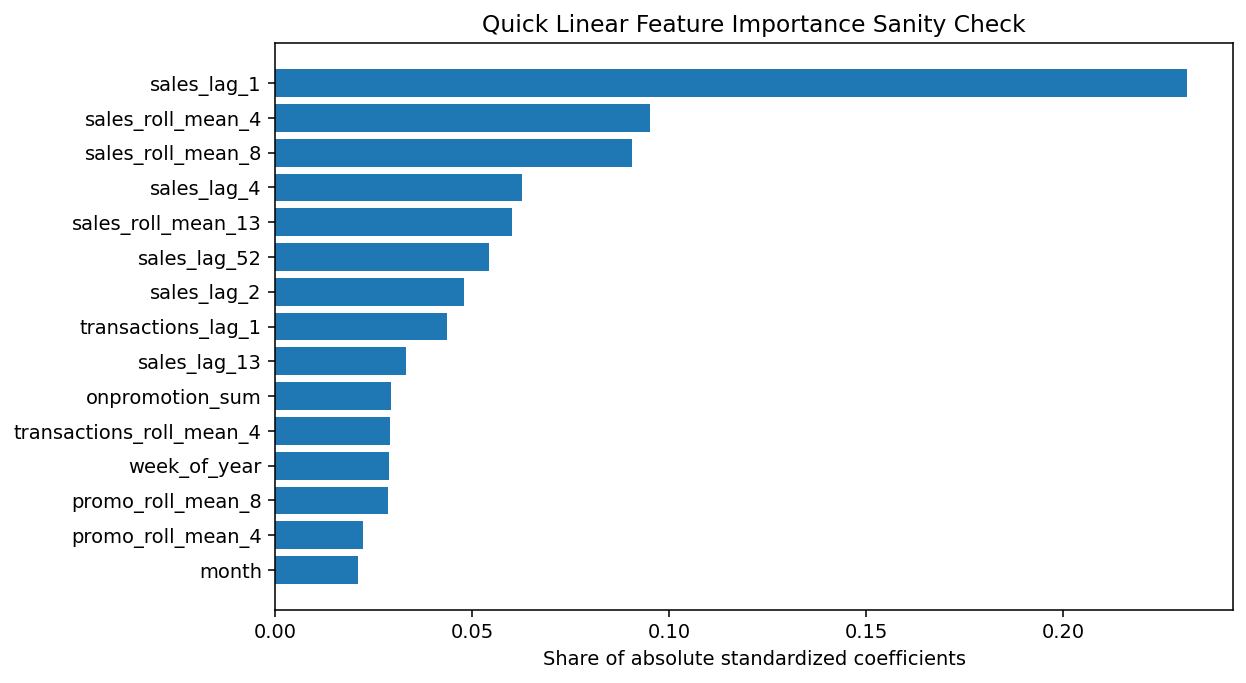

,feature,abs_standardized_coefficient,importance_share
0,sales_lag_1,0.420086,0.231379
5,sales_roll_mean_4,0.172786,0.095169
6,sales_roll_mean_8,0.164268,0.090477
2,sales_lag_4,0.113802,0.062681
7,sales_roll_mean_13,0.108901,0.059982
4,sales_lag_52,0.098300,0.054143
1,sales_lag_2,0.086704,0.047756
34,transactions_lag_1,0.079264,0.043658
3,sales_lag_13,0.060008,0.033052
14,onpromotion_sum,0.053176,0.029289


In [25]:
numeric_feature_columns = [
    "sales_lag_1",
    "sales_lag_2",
    "sales_lag_4",
    "sales_lag_13",
    "sales_lag_52",
    "sales_roll_mean_4",
    "sales_roll_mean_8",
    "sales_roll_mean_13",
    "sales_roll_std_4",
    "sales_roll_std_8",
    "sales_roll_std_13",
    "sales_roll_zero_rate_4",
    "sales_roll_zero_rate_8",
    "sales_roll_zero_rate_13",
    "onpromotion_sum",
    "onpromotion_max",
    "promo_flag",
    "promo_lag_1",
    "promo_lag_4",
    "promo_lag_13",
    "promo_roll_mean_4",
    "promo_roll_mean_8",
    "promo_roll_mean_13",
    "holiday_normal",
    "holiday_transferred_original",
    "holiday_transfer_effect",
    "holiday_bridge",
    "holiday_workday",
    "holiday_additional",
    "holiday_event",
    "oil_weekly_mean",
    "oil_weekly_change",
    "oil_change_lag_1",
    "oil_change_lag_4",
    "transactions_lag_1",
    "transactions_lag_4",
    "transactions_lag_13",
    "transactions_roll_mean_4",
    "transactions_roll_mean_13",
    "week_of_year",
    "month",
    "quarter",
    "year",
    "is_year_end_week",
    "store_nbr_code",
    "family_code",
    "city_code",
    "state_code",
    "type_code",
    "cluster_code",
]
quick_importance = quick_linear_importance(weekly_features, numeric_feature_columns, "sales", 200_000)
quick_importance.to_csv(P3_TABLE_DIR / "quick_linear_feature_importance.csv", index=False)
assert quick_importance.iloc[0]["importance_share"] < 0.60, "One feature dominates the quick model sanity check"

fig, ax = plt.subplots(figsize=(9, 5))
plot_importance = quick_importance.head(15).sort_values("importance_share")
ax.barh(plot_importance["feature"], plot_importance["importance_share"])
ax.set_title("Quick Linear Feature Importance Sanity Check")
ax.set_xlabel("Share of absolute standardized coefficients")
save_and_show(fig, P3_FIGURE_DIR / "quick_linear_feature_importance.png")
quick_importance.head(15)

### Freeze Feature Set

The frozen artifact is written for P4. Rows with missing long-history features are retained and explicitly reported; P4 will decide fold eligibility using training windows, not by silently dropping series here.

In [26]:
feature_columns = [
    "store_nbr",
    "family",
    "week_start",
    "sales",
    "daily_rows",
    "city",
    "state",
    "type",
    "cluster",
] + numeric_feature_columns

features_frozen = weekly_features[feature_columns].sort_values(["store_nbr", "family", "week_start"]).reset_index(drop=True)
features_frozen.to_parquet(FEATURE_PATH, index=False)

feature_rationale = pd.DataFrame(
    [
        {"feature_group": "sales_lags", "rationale": "P1 identified weekly and seasonal dependence; shifted lags enforce no lookahead."},
        {"feature_group": "rolling_sales", "rationale": "P1 intermittency and variance profiles require recent level, volatility, and zero-rate history."},
        {"feature_group": "calendar_holidays", "rationale": "P1 closures and P2 transferred-holiday evidence require explicit holiday handling."},
        {"feature_group": "promotion", "rationale": "P2 measured large heterogeneous promotion response."},
        {"feature_group": "oil", "rationale": "P2 found weak relationship; retained as cautious upper-level exogenous context from the constitution."},
        {"feature_group": "transactions", "rationale": "P2 found strong footfall relationship; only lagged/rolling history is included to avoid leakage."},
        {"feature_group": "store_attributes", "rationale": "P2 found demand-shape differences by store geography and cluster."},
    ]
)
feature_rationale.to_csv(P3_TABLE_DIR / "feature_rationale.csv", index=False)

feature_set_summary = pd.DataFrame(
    {
        "metric": [
            "rows",
            "columns",
            "bottom_series",
            "min_week_start",
            "max_week_start",
            "rows_with_sales_lag_52",
            "leakage_canary_detected",
        ],
        "value": [
            len(features_frozen),
            features_frozen.shape[1],
            features_frozen[["store_nbr", "family"]].drop_duplicates().shape[0],
            str(features_frozen["week_start"].min().date()),
            str(features_frozen["week_start"].max().date()),
            int(features_frozen["sales_lag_52"].notna().sum()),
            str(leakage_canary_detected),
        ],
    }
)
feature_set_summary.to_csv(P3_TABLE_DIR / "feature_set_summary.csv", index=False)

assert FEATURE_PATH.exists()
assert features_frozen["sales"].notna().all()
assert features_frozen[["store_nbr", "family", "week_start"]].duplicated().sum() == 0
feature_set_summary

,metric,value
0,rows,351945
1,columns,59
2,bottom_series,1729
3,min_week_start,2012-12-31
4,max_week_start,2017-08-14
5,rows_with_sales_lag_52,263421
6,leakage_canary_detected,True


### P3 Findings

**Feature set frozen**

- Weekly bottom-level feature artifact: `data/processed/features.parquet`.
- Rationale table: `outputs/metrics/p3_features/feature_rationale.csv`.
- Lineage table: `outputs/metrics/p3_features/feature_lineage.csv`.

**P3 exit criteria status**

- Every feature has a stated rationale traceable to P1 or P2: done in `feature_rationale.csv`.
- No feature uses data from `t` or later at forecast origin `t`: asserted by shifted lag checks and `feature_lineage.csv`.
- Leakage canary test passes: done in `leakage_canary.csv`.
- Feature importance sanity check on a quick model: done in `quick_linear_feature_importance.csv` and figure.
- Feature set frozen and documented: done in `data/processed/features.parquet` and this section.
